### 4.2 Modeling/4.3 Feature selection

In [3]:
import pandas as pd
import pickle
from sklearn.metrics import accuracy_score, classification_report, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

def make_pipeline(classifier):
    """Creates a machine learning pipeline with a Random Forest Classifier.

    Returns:
        Pipeline: A scikit-learn pipeline with a RandomForestClassifier as the final step.
    """
    steps = [("classifier", classifier)]
    pipe = Pipeline(steps)
    return pipe

def train(df, classifier):
    """Trains a Random Forest model using the specified DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the features and target variable.

    Returns:
        Pipeline: The trained RandomForest model pipeline.
    """
    # We are predicting the protein labels
    y = df["label"]
    target = "label"
    features = list(df.columns)
    
    features.remove(target)

    # Select all columns starting with 'onehot' for features
    x = df[features]

    # Split data into train and test sets
    x_train, x_test, y_train, y_test = balanced_group_train_test_split(
        x,
        y,
        group_col='augmentated from uniprot ID',
        test_size=0.2,
        random_state=42
    )

    # Count positive and negative labels in y_train and y_test
    y_train_counts = y_train.value_counts()
    y_test_counts = y_test.value_counts()

    print("Label counts in y_train:")
    print(y_train_counts)

    print("\nLabel counts in y_test:")
    print(y_test_counts)

    trained_model = make_pipeline(classifier)
    trained_model.fit(x_train, y_train)

    # Make predictions
    y_train_pred = trained_model.predict(x_train)
    y_test_pred = trained_model.predict(x_test)


    # Calculate model metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_mcc = matthews_corrcoef(y_train, y_train_pred)
    test_mcc = matthews_corrcoef(y_test, y_test_pred)
    
    train_report = classification_report(y_train, y_train_pred, zero_division=1)
    test_report = classification_report(y_test, y_test_pred, zero_division=1)

        # Print metrics in a readable format
    print(f"Model {classifier} Performance Metrics:\n")
    
    print("Training Data Metrics:")
    print(f"Accuracy: {train_accuracy:.2f}")
    print(f"MCC: {train_mcc:.2f}")
    print("Classification Report:")
    print(train_report)
    
    print("\nTest Data Metrics:")
    print(f"Accuracy: {test_accuracy:.2f}")
    print(f"MCC: {test_mcc:.2f}")
    print("Classification Report:")
    print(test_report)

    

    print("Successfully trained the model.")
    return trained_model

def evaluation(df, trained_model):
    """evaluation a model using the specified DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the features and target variable.

    Returns:
        None
    """
    # We are predicting the protein labels
    y = df["label"]
    target = "label"
    features = list(df.columns)
    
    features.remove(target)

    # Select all columns starting with 'onehot' for features
    x = df[features]


    # Count positive and negative labels in y_train and y_test
    y_counts = y.value_counts()

    print("Label counts in y:")
    print(y_counts)

    # Make predictions
    y_test_pred = trained_model.predict(x)


    # Calculate model metrics
    test_accuracy = accuracy_score(y, y_test_pred)
    
    test_mcc = matthews_corrcoef(y, y_test_pred)
    
    test_report = classification_report(y, y_test_pred, zero_division=1)

        # Print metrics in a readable format
    print(f"Model {trained_model} Performance Metrics:\n")
    
    
    print("\nTest Data Metrics:")
    print(f"Accuracy: {test_accuracy:.2f}")
    print(f"MCC: {test_mcc:.2f}")
    print("Classification Report:")
    print(test_report)

    print("Successfully evaluated the model.")
    return None   

In [4]:
# Customized the train_test_split for augmentated dataset
import numpy as np
import pandas as pd
from sklearn.utils import shuffle

def balanced_group_train_test_split(X, y, group_col='augmented_from_uniprot_id', 
                                   test_size=0.2, random_state=42, drop_group_col = True):
    """
    Splits data into balanced train/test sets while keeping augmented groups together.
    
    Parameters:
    X (pd.DataFrame): Feature dataframe containing the group column
    y (pd.Series): Target labels
    group_col (str): Name of the column containing group IDs
    test_size (float): Proportion of data for testing (default 0.2)
    random_state (int): Random seed for reproducibility
    
    Returns:
    (pd.DataFrame, pd.DataFrame, pd.Series, pd.Series): X_train, X_test, y_train, y_test
    """
    # Validate inputs
    if group_col not in X.columns:
        raise ValueError(f"Group column '{group_col}' not found in feature dataframe")
        
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of samples")

    rng = np.random.RandomState(random_state)
    combined = X.copy()
    combined['_label'] = y.values

    # Create group metadata
    group_meta = combined.groupby(group_col).agg({
        '_label': 'first',
        group_col: 'count'
    }).rename(columns={group_col: 'count'}).reset_index()

    train_groups, test_groups = [], []

    # Stratified group splitting
    for label in group_meta['_label'].unique():
        label_groups = group_meta[group_meta['_label'] == label]
        total_samples = label_groups['count'].sum()
        test_samples_target = int(total_samples * test_size)
        
        label_groups = shuffle(label_groups, random_state=rng)
        
        # Select groups for test set
        cumulative, selected = 0, []
        for _, row in label_groups.iterrows():
            if cumulative >= test_samples_target:
                break
            selected.append(row[group_col])
            cumulative += row['count']
        
        # Assign remaining groups to train
        remaining = list(set(label_groups[group_col]) - set(selected))
        test_groups.extend(selected)
        train_groups.extend(remaining)

    # Create splits
    train_mask = combined[group_col].isin(train_groups)
    test_mask = combined[group_col].isin(test_groups)

    if drop_group_col:
        return (
                X[train_mask].drop(columns=[group_col]),
                X[test_mask].drop(columns=[group_col]),
                y[train_mask],
                y[test_mask])
    else:
        return (
                X[train_mask],
                X[test_mask],
                y[train_mask],
                y[test_mask])

# Analysis bio feature, look for the co linear feature in it, exclude some of those features

In [5]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]

In [6]:
excluded_prefixes = (
    'esm_protein_embedding_',
    'esm_residue_embedding_',
    'ptmmamba_residue_embedding_',
    'ptmmamba_protein_embedding_',
    'onehot_'
)

exclude_columns = ['Unnamed: 0', 'uniprot_id', 'sequence', 'site',  'human Site and Mutation', 'usage',
       'unique_id', "anchor_score", "augmentated from uniprot ID"]

# Create a list of columns to keep (those that don't start with excluded prefixes)
columns_to_keep = [col for col in training_dataset_df.columns if not any(col.startswith(prefix) for prefix in excluded_prefixes)]
bio_columns_to_keep = [col for col in columns_to_keep if col not in exclude_columns]
# Now select those columns from your DataFrame
biology_training_dataset_df = training_dataset_df[bio_columns_to_keep]

In [7]:
biology_training_dataset_df.head(2)

,label,deephase_phys_multi,deephase_w2v_multi,deephase_score,iupred_score,nuSVR,SconfSVR/N (kB),mean_lambda,SHD,SCD,kappa,FCR,NCPR,fK,fR,fE,fD,faro,phospho_score
0,1,0.203,0.160,0.182,0.541878,0.556,10.595,0.324,1.403,-0.950,0.363,0.385,-0.077,0.077,0.077,0.0,0.154,0.0,0.526
1,1,0.185,0.173,0.179,0.509769,0.732,10.867,0.388,0.970,-0.546,-1.000,0.600,0.200,0.200,0.200,0.0,0.000,0.0,0.579


In [8]:
biology_training_dataset_df.columns

Index(['label', 'deephase_phys_multi', 'deephase_w2v_multi', 'deephase_score',
       'iupred_score', 'nuSVR', 'SconfSVR/N (kB)', 'mean_lambda', 'SHD', 'SCD',
       'kappa', 'FCR', 'NCPR', 'fK', 'fR', 'fE', 'fD', 'faro',
       'phospho_score'],
      dtype='object')

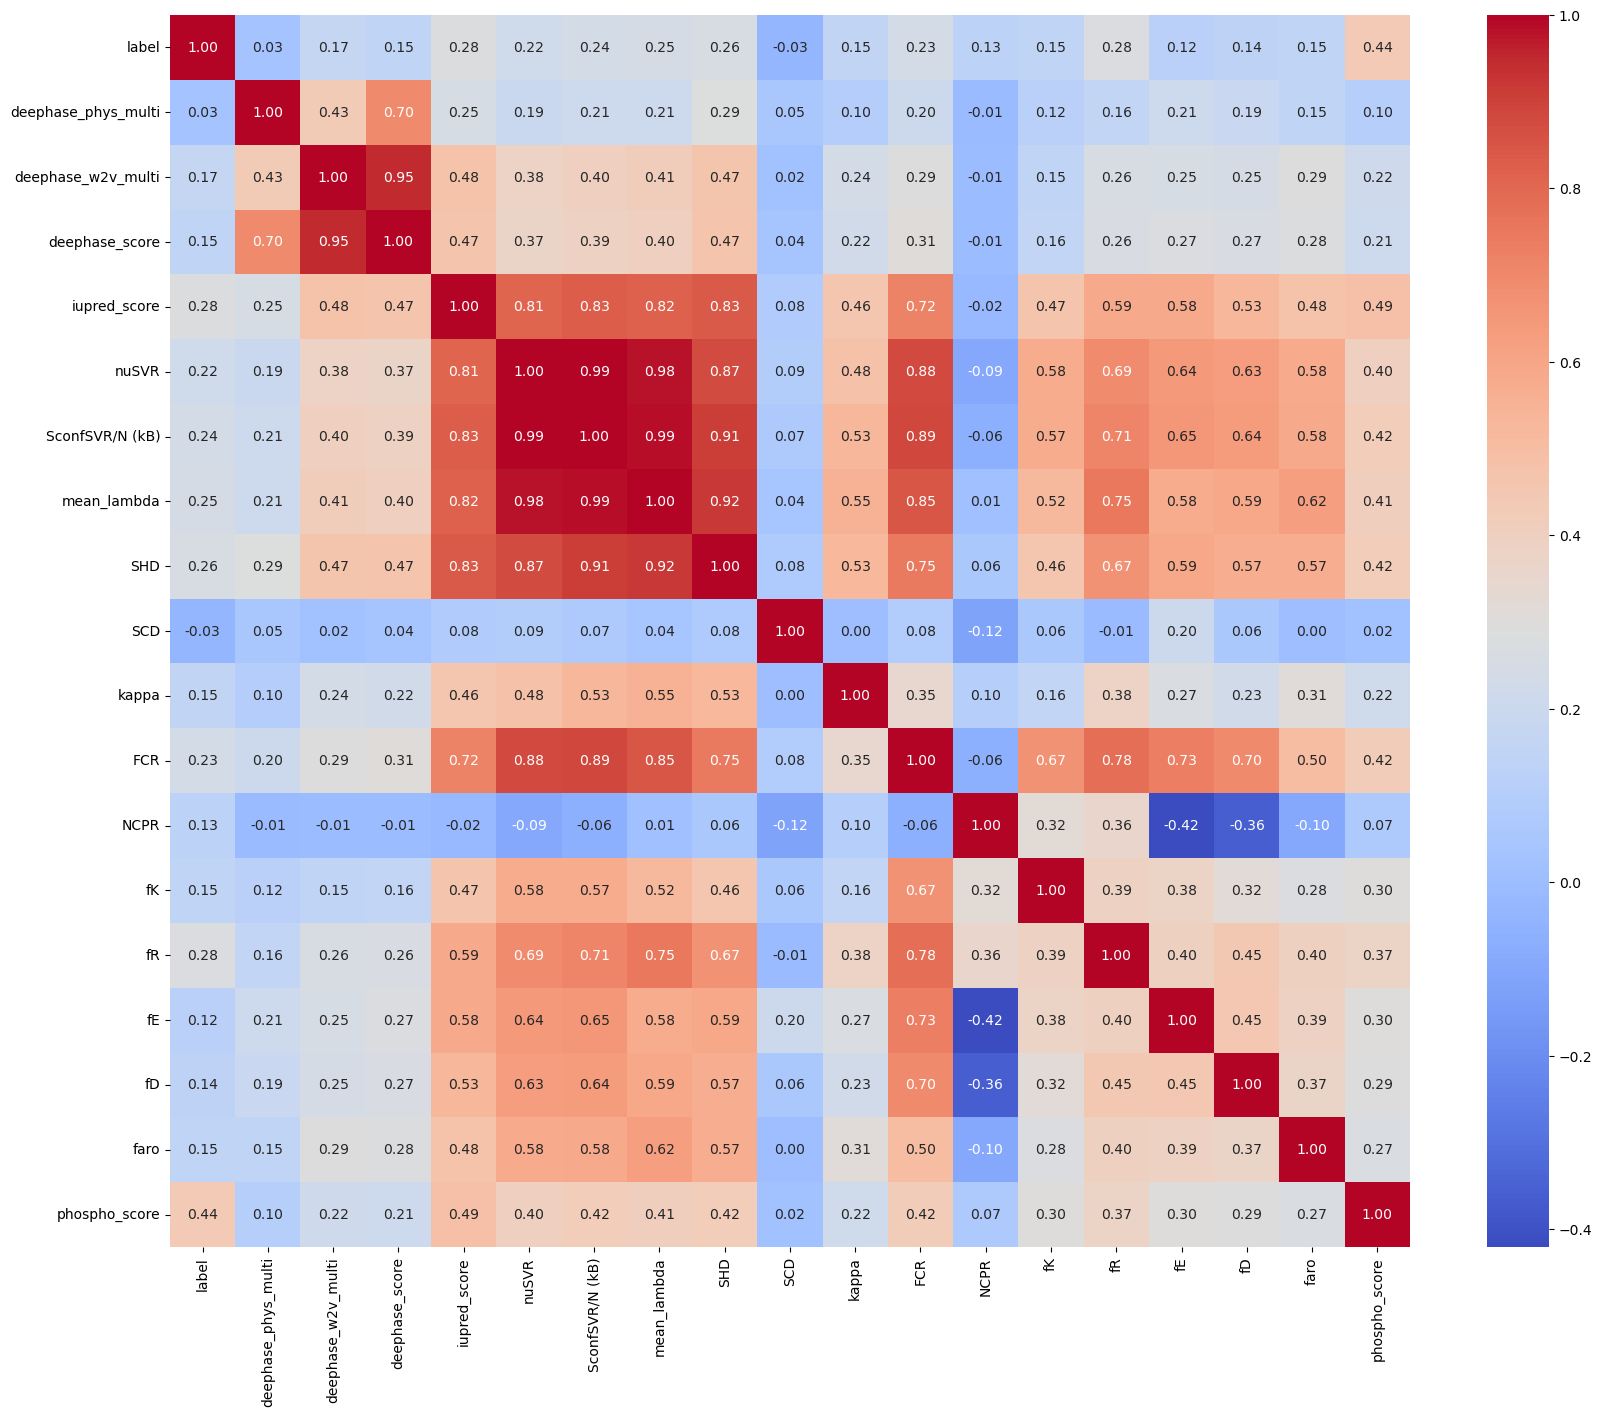

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
# Set the figure size
plt.figure(figsize=(20, 16))  # Adjust the size as needed

# Create the heatmap
sns.heatmap(biology_training_dataset_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

# Show the plot
plt.show()

In [10]:
always_exclude_columns = ['Unnamed: 0', 'uniprot_id', 'sequence', 'site',  'human Site and Mutation', 'usage','unique_id', 
                          "anchor_score", 'onehot_0_s', 'onehot_0_t','SconfSVR/N (kB)', 'mean_lambda', 'SHD', 'fE', 'fR','fD', "FCR", 
                          'deephase_phys_multi', 'deephase_score']

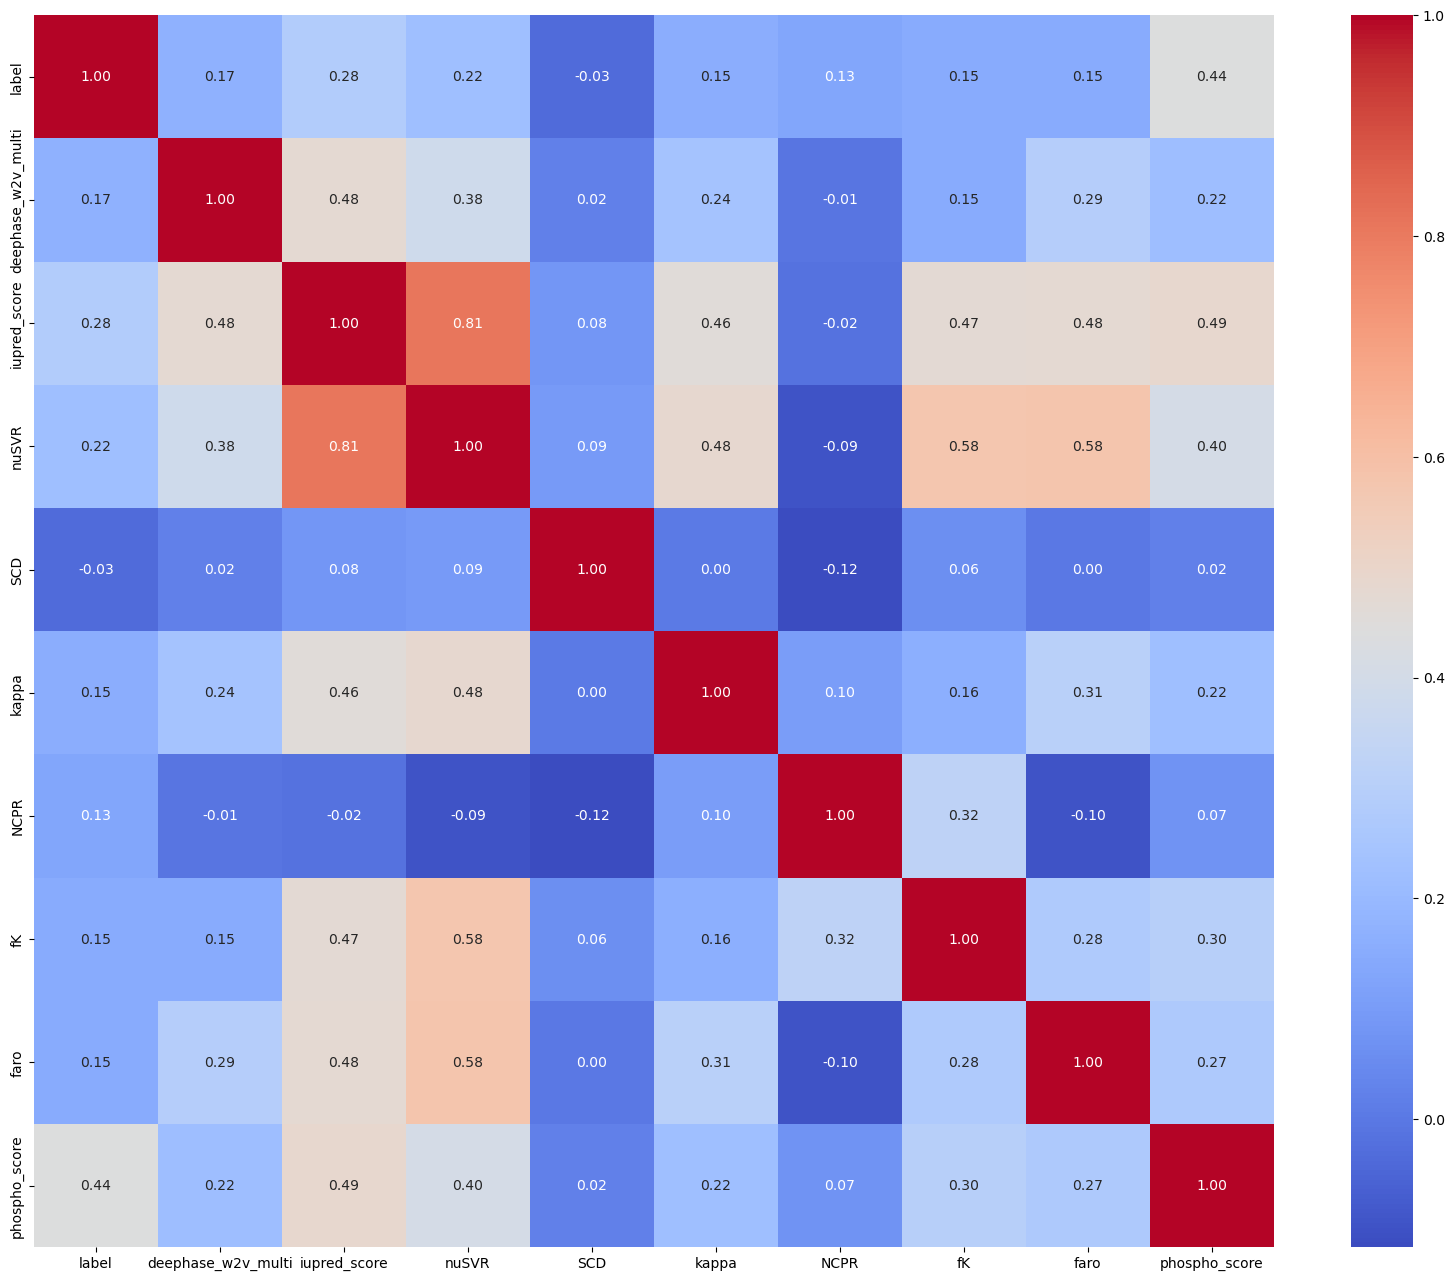

In [11]:
# Create a list of columns to keep (those that don't start with excluded prefixes)
columns_to_keep = [col for col in training_dataset_df.columns if not any(col.startswith(prefix) for prefix in excluded_prefixes)]
bio_columns_to_keep = [col for col in columns_to_keep if col not in always_exclude_columns]
# Now select those columns from your DataFrame
bio_columns_to_keep.remove("augmentated from uniprot ID")

biology_training_dataset_df = training_dataset_df[bio_columns_to_keep]

# Set the figure size
plt.figure(figsize=(20, 16))  # Adjust the size as needed

# Create the heatmap
sns.heatmap(biology_training_dataset_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

# Show the plot
plt.show()

# task 35: # 1. prove data augmentation is helpful for modeling
# model from no_augmentated model compare with augmentated model using only onehot encode

In [ ]:
# get augmentated and no_augmentated training dataset, only include onehot encode feature
dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")

# get independent test dataset, only include onehot encode feature
training_dataset_df = dataset_df[dataset_df["usage"] == "training"]
no_postive_augmentated_training_dataset_df = training_dataset_df[training_dataset_df["uniprot_id"]==training_dataset_df["augmentated from uniprot ID"]]

onehot_augmentated_dataset_df = training_dataset_df.filter(regex=r'^(onehot_|label|augmentated from uniprot ID)')
onehot_no_augmentated_dataset_df = no_augmentated_training_dataset_df.filter(regex=r'^(onehot_|label|augmentated from uniprot ID)')
onehot_test_dataset_df = dataset_df[dataset_df["usage"] == "independent test"].filter(regex=r'^(onehot_|label)')

In [10]:
# get augmentated and no_augmentated training dataset, only include onehot encode feature
dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")

# get independent test dataset, only include onehot encode feature
training_dataset_df = dataset_df[dataset_df["usage"] == "training"]
no_postive_augmentated_training_dataset_df = training_dataset_df[training_dataset_df["uniprot_id"]==training_dataset_df["augmentated from uniprot ID"]]

In [11]:
negative_dataset = pd.read_csv("labeled_and_augmented_negative_data.csv")
negative_dataset.head(2)

,Unnamed: 0,index,uniqueid,uniprot_id,position,prot_id_position,protein_length,iupred_score,anchor_score,phospho_score,binned_protein_length,binned_iupred_score,binned_anchor_score,binned_phospho_score,stratification_label,label,augmentated data?,homology data?
0,0,309110,P51843_S_457,P51843,457,P51843_457,470,0.013821,0.424671,0.044,0,0,1,0,0_0_1_0,0,1,0
1,1,270130,P62324_S_90,P62324,90,P62324_90,171,0.185198,0.427061,0.105,0,0,1,0,0_0_1_0,0,1,0


In [12]:
def filter_out_augmented_entries(main_df, negative_df):
    """
    Filter out rows from main_df where the same uniprot_id and position 
    are labeled as augmented in negative_df.
    
    Args:
        main_df (pd.DataFrame): The main dataframe to filter
        negative_df (pd.DataFrame): The negative dataset with augmented labels
        
    Returns:
        pd.DataFrame: Filtered dataframe
    """
    # Find augmented entries in the negative dataset
    augmented_negative = negative_df[negative_df['augmentated data?'] == 1]
    
    # Create a set of (uniprot_id, position) pairs that are augmented in negative dataset
    augmented_pairs = set(zip(augmented_negative['uniprot_id'], augmented_negative['position']))
    
    # Filter the main dataframe to exclude rows with matching (uniprot_id, position) pairs
    filtered_df = main_df[~main_df.apply(
        lambda row: (row['uniprot_id'], row['site']) in augmented_pairs, 
        axis=1
    )]
    
    return filtered_df

In [13]:
# exclude the negative augmentated dataset
no_augmentated_training_dataset_df = filter_out_augmented_entries(no_postive_augmentated_training_dataset_df, negative_dataset)

In [14]:
no_augmentated_training_dataset_df

,Unnamed: 0,uniprot_id,sequence,site,label,augmentated from uniprot ID,human Site and Mutation,usage,unique_id,deephase_phys_multi,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
656,656,Q12809,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1137,1,Q12809,S1137s,training,Q12809_1137_MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANA...,0.251,...,-1.783180,-0.304031,-0.288107,0.164548,-0.551381,-0.128719,-1.041860,0.181813,-0.047576,0.536
657,657,Q12809,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,283,1,Q12809,S283s,training,Q12809_283_MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANAR...,0.251,...,-1.806326,-0.828657,0.649456,1.450973,0.653022,-0.550002,-1.043735,0.340695,-0.834819,0.559
661,661,Q53EL6,MDVENEQILNVNPADPDNLSDSLFSGDEENAGTEEIKNEINGNWIS...,457,1,Q53EL6,S457s,training,Q53EL6_457_MDVENEQILNVNPADPDNLSDSLFSGDEENAGTEE...,0.253,...,-1.038290,-1.411181,-0.506342,-1.455358,1.592491,1.660902,0.631469,-0.082601,-0.395762,0.574
662,662,Q53EL6,MDVENEQILNVNPADPDNLSDSLFSGDEENAGTEEIKNEINGNWIS...,76,1,Q53EL6,S76s,training,Q53EL6_76_MDVENEQILNVNPADPDNLSDSLFSGDEENAGTEEI...,0.253,...,-2.255229,-0.687755,-0.409781,-0.000571,-0.095428,1.090727,-0.278532,-0.292084,-0.407974,0.792
667,667,Q16584,MEPLKSLFLKSPLGSWNGSGSGGGGGGGGGRPEGSPKAAGYANPVW...,477,1,Q16584,T477t,training,Q16584_477_MEPLKSLFLKSPLGSWNGSGSGGGGGGGGGRPEGS...,0.279,...,-1.110806,0.015970,0.010673,0.165749,-0.105785,-0.907999,-0.538865,0.178536,-0.496697,0.540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1512,1512,P07359,MPLLLLLLLLPSPLHPHPICEVSKVASHLEVNCDKRNLTALPPDLP...,163,0,P07359,T163t,training,P07359_163_MPLLLLLLLLPSPLHPHPICEVSKVASHLEVNCDK...,0.184,...,-2.151117,-0.365751,0.100583,0.527544,0.326141,-0.702853,0.042790,2.066671,0.122529,0.036
2188,2188,Q8WV28,MDKLNKITVPASQKLRQLQKMVHDIKNNEGGIMNKIKKLKVKAPPS...,144,0,Q8WV28,S144s,training,Q8WV28_144_MDKLNKITVPASQKLRQLQKMVHDIKNNEGGIMNK...,0.268,...,-2.612988,0.002217,1.884787,0.551916,0.957121,0.635466,-1.360663,1.111972,1.553928,0.041
2213,2213,Q5D1E8,MSGPCGEKPVLEASPTMSLWEFEDSHSRQGTPRPGQELAAEEASAL...,362,0,Q5D1E8,S362s,training,Q5D1E8_362_MSGPCGEKPVLEASPTMSLWEFEDSHSRQGTPRPG...,0.278,...,-2.303561,0.059922,0.788983,-0.363295,0.234735,0.931589,-0.319640,1.455369,-0.062593,0.269
2225,2225,Q96E09,MAQEKMELDLELPPGTGGSPAEGGGSGGGGGLRRSNSAPLIHGLSD...,122,0,Q96E09,S122s,training,Q96E09_122_MAQEKMELDLELPPGTGGSPAEGGGSGGGGGLRRS...,0.191,...,-1.569469,-0.652345,0.701813,0.122008,0.720703,1.335228,0.233918,-0.800321,0.051862,0.054


In [15]:
onehot_augmentated_dataset_df = training_dataset_df.filter(regex=r'^(onehot_|label|augmentated from uniprot ID)')
onehot_no_augmentated_dataset_df = no_augmentated_training_dataset_df.filter(regex=r'^(onehot_|label|augmentated from uniprot ID)')
onehot_test_dataset_df = dataset_df[dataset_df["usage"] == "independent test"].filter(regex=r'^(onehot_|label)')

In [16]:
# training two model
augmentated_model = train(onehot_augmentated_dataset_df, RandomForestClassifier(max_depth=7,random_state=42))
no_augmentated_model = train(onehot_no_augmentated_dataset_df, RandomForestClassifier(max_depth=7,random_state=42))

Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7, random_state=42) Performance Metrics:

Training Data Metrics:
Accuracy: 0.90
MCC: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       966
           1       0.89      0.89      0.89       841

    accuracy                           0.90      1807
   macro avg       0.90      0.90      0.90      1807
weighted avg       0.90      0.90      0.90      1807


Test Data Metrics:
Accuracy: 0.82
MCC: 0.65
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       233
           1       0.85      0.77      0.81       226

    accuracy                           0.82       459
   macro avg       0.83      0.82      0.82       459
weighted avg       0.83      0.

In [17]:
# evaluate both model in independent test dataset

In [18]:
print("evaluate model trained with augmentated data")
evaluation(onehot_test_dataset_df, augmentated_model)

evaluate model trained with augmentated data
Label counts in y:
label
0    264
1    263
Name: count, dtype: int64
Model Pipeline(steps=[('classifier',
                 RandomForestClassifier(max_depth=7, random_state=42))]) Performance Metrics:


Test Data Metrics:
Accuracy: 0.82
MCC: 0.65
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.94      0.84       264
           1       0.92      0.69      0.79       263

    accuracy                           0.82       527
   macro avg       0.84      0.82      0.81       527
weighted avg       0.84      0.82      0.81       527

Successfully evaluated the model.


In [19]:
print("evaluate model trained with no augmentated data")
evaluation(onehot_test_dataset_df, no_augmentated_model)

evaluate model trained with no augmentated data
Label counts in y:
label
0    264
1    263
Name: count, dtype: int64
Model Pipeline(steps=[('classifier',
                 RandomForestClassifier(max_depth=7, random_state=42))]) Performance Metrics:


Test Data Metrics:
Accuracy: 0.77
MCC: 0.59
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.97      0.81       264
           1       0.95      0.56      0.71       263

    accuracy                           0.77       527
   macro avg       0.82      0.77      0.76       527
weighted avg       0.82      0.77      0.76       527

Successfully evaluated the model.


task 37: Then we tested modeling from multi-scale biology features plus onehot encoding for the -7 to +7 motif, the result show that multi-scale biology features also can be used to predict the 14-3-3 binding when compare with only use onehot encoded motif feature. 

In [20]:
# we first test to only use onehot encoding for the prediction

In [21]:
onehot_training_dataset_df = training_dataset_df.filter(regex=r'^(onehot_|label|augmentated from uniprot ID)')
onehot_training_dataset_df

,label,augmentated from uniprot ID,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,onehot_-7_F,onehot_-7_G,onehot_-7_H,onehot_-7_I,...,onehot_7_P,onehot_7_Q,onehot_7_R,onehot_7_S,onehot_7_T,onehot_7_V,onehot_7_W,onehot_7_Y,onehot_7_s,onehot_7_t
0,1,P16333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,P16333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,P16333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,P16333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,Q5VWQ8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,0,O15417,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2262,0,Q9BYW2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2263,0,Q8N3K9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2264,0,Q6ZRS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
print(f"Modeling only use onehot encoding features")
model = train(onehot_training_dataset_df, RandomForestClassifier(max_depth=7,random_state=42))

Modeling only use onehot encoding features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7, random_state=42) Performance Metrics:

Training Data Metrics:
Accuracy: 0.90
MCC: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       966
           1       0.89      0.89      0.89       841

    accuracy                           0.90      1807
   macro avg       0.90      0.90      0.90      1807
weighted avg       0.90      0.90      0.90      1807


Test Data Metrics:
Accuracy: 0.82
MCC: 0.65
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       233
           1       0.85      0.77      0.81       226

    accuracy                           0.82       459
   macro avg       0.83      0.82      0.8

In [23]:
# then we test use both onehot encode and biological features

In [24]:
excluded_prefixes = (
    'esm_protein_embedding_',
    'esm_residue_embedding_',
    'ptmmamba_residue_embedding_',
    'ptmmamba_protein_embedding_'
)

# Create a list of columns to keep (those that don't start with excluded prefixes)
columns_to_keep = [col for col in training_dataset_df.columns if not any(col.startswith(prefix) for prefix in excluded_prefixes)]
bio_columns_to_keep = [col for col in columns_to_keep if col not in always_exclude_columns]
# Now select those columns from your DataFrame
biology_training_dataset_df = training_dataset_df[bio_columns_to_keep]

In [25]:
biology_training_dataset_df.head(2)

,label,augmentated from uniprot ID,deephase_w2v_multi,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,onehot_-7_F,onehot_-7_G,...,onehot_7_Y,onehot_7_s,onehot_7_t,nuSVR,SCD,kappa,NCPR,fK,faro,phospho_score
0,1,P16333,0.160,0.541878,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.556,-0.950,0.363,-0.077,0.077,0.0,0.526
1,1,P16333,0.173,0.509769,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.732,-0.546,-1.000,0.200,0.200,0.0,0.579


In [26]:
print(f"Modeling using multi-scale biology features")
model = train(biology_training_dataset_df, RandomForestClassifier(max_depth=7,random_state=42))

Modeling using multi-scale biology features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7, random_state=42) Performance Metrics:

Training Data Metrics:
Accuracy: 0.90
MCC: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       966
           1       0.90      0.90      0.90       841

    accuracy                           0.90      1807
   macro avg       0.90      0.90      0.90      1807
weighted avg       0.90      0.90      0.90      1807


Test Data Metrics:
Accuracy: 0.83
MCC: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       233
           1       0.86      0.78      0.82       226

    accuracy                           0.83       459
   macro avg       0.83      0.83      0.

In [27]:
import gc
gc.collect()

11791

task 36: modeling direct from only PLM embedding, we first compare using embeddings from either ESM2 or PTM-mamba to represent the whole protein or the residue embeddings, 

In [28]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]

In [29]:
training_dataset_df.head(2)

,Unnamed: 0,uniprot_id,sequence,site,label,augmentated from uniprot ID,human Site and Mutation,usage,unique_id,deephase_phys_multi,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
0,0,H7C5C7,XVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMNKTGFVPSNYVER...,73,1,P16333,S73s,training,H7C5C7_73_XVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMNKT...,0.203,...,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624,0.526
1,1,A0A5F9CW23,MAEEVVVVAKFDYVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMN...,85,1,P16333,S85s,training,A0A5F9CW23_85_MAEEVVVVAKFDYVAQQEQELDIKKNERLWLL...,0.185,...,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350,0.579


In [30]:
columns = training_dataset_df.columns
columns

Index(['Unnamed: 0', 'uniprot_id', 'sequence', 'site', 'label',
       'augmentated from uniprot ID', 'human Site and Mutation', 'usage',
       'unique_id', 'deephase_phys_multi',
       ...
       'ptmmamba_residue_embedding_759', 'ptmmamba_residue_embedding_760',
       'ptmmamba_residue_embedding_761', 'ptmmamba_residue_embedding_762',
       'ptmmamba_residue_embedding_763', 'ptmmamba_residue_embedding_764',
       'ptmmamba_residue_embedding_765', 'ptmmamba_residue_embedding_766',
       'ptmmamba_residue_embedding_767', 'phospho_score'],
      dtype='object', length=4454)

In [31]:
esm_training_dataset_df = training_dataset_df.filter(regex=r'^(esm_protein_embedding_|esm_residue_embedding_|label|augmentated from uniprot ID)')
ptmmamba_training_dataset_df = training_dataset_df.filter(regex=r'^(ptmmamba_residue_embedding|ptmmamba_protein_embedding_position|label|augmentated from uniprot ID)')

In [32]:
esm_training_dataset_df.head(2)

,label,augmentated from uniprot ID,esm_protein_embedding_0,esm_protein_embedding_1,esm_protein_embedding_2,esm_protein_embedding_3,esm_protein_embedding_4,esm_protein_embedding_5,esm_protein_embedding_6,esm_protein_embedding_7,...,esm_residue_embedding_1270,esm_residue_embedding_1271,esm_residue_embedding_1272,esm_residue_embedding_1273,esm_residue_embedding_1274,esm_residue_embedding_1275,esm_residue_embedding_1276,esm_residue_embedding_1277,esm_residue_embedding_1278,esm_residue_embedding_1279
0,1,P16333,0.021365,-0.020171,0.021621,0.095043,-0.057202,-0.050794,0.071949,0.006663,...,0.156998,-0.048794,-0.288164,-0.169802,-0.087454,-0.099428,-0.027398,-0.170118,-0.108479,-0.087466
1,1,P16333,0.024337,-0.044602,0.026486,0.129851,-0.089049,-0.042135,0.083374,0.002857,...,0.155553,-0.035488,-0.296511,-0.183268,-0.062212,-0.104337,-0.041655,-0.249533,-0.119220,-0.131040


In [33]:
ptmmamba_training_dataset_df.head(2)

,label,augmentated from uniprot ID,ptmmamba_protein_embedding_position_0,ptmmamba_protein_embedding_position_1,ptmmamba_protein_embedding_position_2,ptmmamba_protein_embedding_position_3,ptmmamba_protein_embedding_position_4,ptmmamba_protein_embedding_position_5,ptmmamba_protein_embedding_position_6,ptmmamba_protein_embedding_position_7,...,ptmmamba_residue_embedding_758,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767
0,1,P16333,0.306219,0.075793,0.279163,0.129615,-0.124552,0.055463,-0.138853,-0.701024,...,0.905219,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624
1,1,P16333,0.164579,-0.161845,0.364336,0.196843,-0.142813,-0.032246,-0.274839,-0.841149,...,1.007017,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350


In [34]:
plm_feature_df_lst = [esm_training_dataset_df, ptmmamba_training_dataset_df]
plm_name_lst = ["esm", "ptmmamba"]

In [35]:
for name, loaded_df in zip(plm_name_lst, plm_feature_df_lst):
    print(f"Modeling using {name}")
    model = train(loaded_df, RandomForestClassifier(max_depth=7,random_state=42))

Modeling using esm
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7, random_state=42) Performance Metrics:

Training Data Metrics:
Accuracy: 0.97
MCC: 0.94
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       966
           1       0.96      0.98      0.97       841

    accuracy                           0.97      1807
   macro avg       0.97      0.97      0.97      1807
weighted avg       0.97      0.97      0.97      1807


Test Data Metrics:
Accuracy: 0.79
MCC: 0.61
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.93      0.82       233
           1       0.90      0.65      0.76       226

    accuracy                           0.79       459
   macro avg       0.82      0.79      0.79       459
weighted avg

In [36]:
import gc
gc.collect()

150

task 38: We then test using both PLM and biology features, the results show that using both PLM and biology features shows improved results compared with using only PLM or multi-scale biology features. 

In [37]:
columns_to_keep = [col for col in training_dataset_df.columns if col not in always_exclude_columns]
plm_bio_features_training_dataset_df = training_dataset_df[columns_to_keep]

In [38]:
import gc

# Force garbage collection
gc.collect()

print(f"Modeling using both PLM and biology features")
model = train(plm_bio_features_training_dataset_df, RandomForestClassifier(max_depth=7,random_state=42))

Modeling using both PLM and biology features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7, random_state=42) Performance Metrics:

Training Data Metrics:
Accuracy: 0.98
MCC: 0.95
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       966
           1       0.96      0.98      0.97       841

    accuracy                           0.98      1807
   macro avg       0.97      0.98      0.98      1807
weighted avg       0.98      0.98      0.98      1807


Test Data Metrics:
Accuracy: 0.81
MCC: 0.63
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.92      0.83       233
           1       0.90      0.69      0.78       226

    accuracy                           0.81       459
   macro avg       0.82      0.80      0

In [39]:
import gc
gc.collect()

25

task 39: feature selection using mRMR. We mainly test how many features are optimized for our model by using different number of features to fit the model and compare the model performance.

In [40]:
# !pip install mrmr_selection

In [41]:
from mrmr import mrmr_classif
from sklearn.metrics import accuracy_score, classification_report, matthews_corrcoef
def mrmr_search_feature_number(df, classifier):
    y = df["label"]
    target = "label"
    features = list(df.columns)
    features.remove(target)
    x = df[features]

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = balanced_group_train_test_split(
        x,
        y,
        group_col='augmentated from uniprot ID',
        test_size=0.2,
        random_state=42
    )

    feature_number_lst = [5,10,20,25,30,40,50,100,200]
    for feature_number in feature_number_lst:
        # using mrmr to get the selected features order
        selected_features = mrmr_classif(X=X_train, y=y_train, K=feature_number)
        print(f"selected feature number is {len(selected_features)}")
        print(selected_features)

        X_train_temp = (X_train).copy()[selected_features]
        X_test_temp = X_test.copy()[selected_features]

        trained_model = make_pipeline(classifier)
        trained_model.fit(X_train_temp, y_train)

        # Make predictions
        y_train_pred = trained_model.predict(X_train_temp)
        y_test_pred = trained_model.predict(X_test_temp)

        # Calculate model metrics
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        
        train_mcc = matthews_corrcoef(y_train, y_train_pred)
        test_mcc = matthews_corrcoef(y_test, y_test_pred)
        
        train_report = classification_report(y_train, y_train_pred, zero_division=1)
        test_report = classification_report(y_test, y_test_pred, zero_division=1)
        
        # Print metrics in a readable format
        print("Model Performance Metrics:\n")
        
        print("Training Data Metrics:")
        print(f"Accuracy: {train_accuracy:.2f}")
        print(f"MCC: {train_mcc:.2f}")
        print("Classification Report:")
        print(train_report)
        
        print("\nTest Data Metrics:")
        print(f"Accuracy: {test_accuracy:.2f}")
        print(f"MCC: {test_mcc:.2f}")
        print("Classification Report:")
        print(test_report)
        
        print(f"\nSuccessfully trained the model with {len(selected_features)} feature{'s' if len(selected_features) > 1 else ''}.")

In [42]:
# first mrmr selection on the biological features

In [43]:
print("biological features mrmr selection")
mrmr_search_feature_number(biology_training_dataset_df, RandomForestClassifier(max_depth=7,random_state=42))

biological features mrmr selection


100%|██████████| 5/5 [00:00<00:00, 21.21it/s]


selected feature number is 5
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.88
MCC: 0.76
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       966
           1       0.86      0.90      0.88       841

    accuracy                           0.88      1807
   macro avg       0.88      0.88      0.88      1807
weighted avg       0.88      0.88      0.88      1807


Test Data Metrics:
Accuracy: 0.82
MCC: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       233
           1       0.83      0.80      0.82       226

    accuracy                           0.82       459
   macro avg       0.82      0.82      0.82       459
weighted avg       0.82      0.82      0.82       459


Successfully trained the model with 5 features.


100%|██████████| 10/10 [00:00<00:00, 16.48it/s]


selected feature number is 10
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'iupred_score', 'onehot_4_L', 'onehot_-3_S']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.89
MCC: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       966
           1       0.86      0.90      0.88       841

    accuracy                           0.89      1807
   macro avg       0.88      0.89      0.89      1807
weighted avg       0.89      0.89      0.89      1807


Test Data Metrics:
Accuracy: 0.80
MCC: 0.61
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.82       233
           1       0.83      0.75      0.79       226

    accuracy                           0.80       459
   macro avg       0.81      0.80      0.80       459
weighted avg       0.81      0.80      0.80       459

...

selected feature number is 50
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'iupred_score', 'onehot_4_L', 'onehot_-3_S', 'onehot_-4_R', 'onehot_-2_G', 'onehot_1_P', 'onehot_-3_V', 'onehot_-2_R', 'onehot_2_K', 'onehot_-3_D', 'onehot_1_R', 'onehot_-3_G', 'onehot_-1_H', 'onehot_-3_A', 'onehot_-5_R', 'nuSVR', 'onehot_3_D', 'onehot_-3_L', 'onehot_-3_N', 'onehot_-3_P', 'deephase_w2v_multi', 'onehot_7_G', 'NCPR', 'onehot_2_A', 'onehot_4_Q', 'onehot_-2_D', 'onehot_2_I', 'onehot_-3_Q', 'onehot_-5_N', 'onehot_2_F', 'onehot_1_E', 'onehot_-2_N', 'onehot_-1_G', 'onehot_-2_L', 'onehot_-1_D', 'fK', 'onehot_1_G', 'onehot_5_H', 'onehot_1_A', 'onehot_-2_F', 'onehot_-6_G', 'onehot_2_L', 'onehot_-3_W']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.89
MCC: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       966
           1       0.88      0.90      0

100%|██████████| 100/100 [00:06<00:00, 15.53it/s]


selected feature number is 100
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'iupred_score', 'onehot_4_L', 'onehot_-3_S', 'onehot_-4_R', 'onehot_-2_G', 'onehot_1_P', 'onehot_-3_V', 'onehot_-2_R', 'onehot_2_K', 'onehot_-3_D', 'onehot_1_R', 'onehot_-3_G', 'onehot_-1_H', 'onehot_-3_A', 'onehot_-5_R', 'nuSVR', 'onehot_3_D', 'onehot_-3_L', 'onehot_-3_N', 'onehot_-3_P', 'deephase_w2v_multi', 'onehot_7_G', 'NCPR', 'onehot_2_A', 'onehot_4_Q', 'onehot_-2_D', 'onehot_2_I', 'onehot_-3_Q', 'onehot_-5_N', 'onehot_2_F', 'onehot_1_E', 'onehot_-2_N', 'onehot_-1_G', 'onehot_-2_L', 'onehot_-1_D', 'fK', 'onehot_1_G', 'onehot_5_H', 'onehot_1_A', 'onehot_-2_F', 'onehot_-6_G', 'onehot_2_L', 'onehot_-3_W', 'onehot_-2_V', 'onehot_-1_N', 'kappa', 'onehot_-2_E', 'onehot_-4_K', 'onehot_-2_P', 'onehot_-5_T', 'onehot_3_R', 'onehot_-1_M', 'onehot_6_Q', 'onehot_-1_E', 'onehot_7_W', 'onehot_-4_G', 'onehot_-2_M', 'onehot_-7_P', 'onehot_-6_R', 'onehot_1_H', 'o

100%|██████████| 200/200 [00:11<00:00, 17.04it/s]


selected feature number is 200
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'iupred_score', 'onehot_4_L', 'onehot_-3_S', 'onehot_-4_R', 'onehot_-2_G', 'onehot_1_P', 'onehot_-3_V', 'onehot_-2_R', 'onehot_2_K', 'onehot_-3_D', 'onehot_1_R', 'onehot_-3_G', 'onehot_-1_H', 'onehot_-3_A', 'onehot_-5_R', 'nuSVR', 'onehot_3_D', 'onehot_-3_L', 'onehot_-3_N', 'onehot_-3_P', 'deephase_w2v_multi', 'onehot_7_G', 'NCPR', 'onehot_2_A', 'onehot_4_Q', 'onehot_-2_D', 'onehot_2_I', 'onehot_-3_Q', 'onehot_-5_N', 'onehot_2_F', 'onehot_1_E', 'onehot_-2_N', 'onehot_-1_G', 'onehot_-2_L', 'onehot_-1_D', 'fK', 'onehot_1_G', 'onehot_5_H', 'onehot_1_A', 'onehot_-2_F', 'onehot_-6_G', 'onehot_2_L', 'onehot_-3_W', 'onehot_-2_V', 'onehot_-1_N', 'kappa', 'onehot_-2_E', 'onehot_-4_K', 'onehot_-2_P', 'onehot_-5_T', 'onehot_3_R', 'onehot_-1_M', 'onehot_6_Q', 'onehot_-1_E', 'onehot_7_W', 'onehot_-4_G', 'onehot_-2_M', 'onehot_-7_P', 'onehot_-6_R', 'onehot_1_H', 'o

In [44]:
# then mrmr selection on all the features

In [45]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]
columns_to_keep = [col for col in training_dataset_df.columns if col not in always_exclude_columns]
training_dataset_df[columns_to_keep]

,label,augmentated from uniprot ID,deephase_w2v_multi,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,onehot_-7_F,onehot_-7_G,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
0,1,P16333,0.160,0.541878,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624,0.526
1,1,P16333,0.173,0.509769,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350,0.579
2,1,P16333,0.129,0.465241,0.0,0.0,0.0,0.0,0.0,1.0,...,-1.474621,-0.104392,1.062815,0.442375,-0.308503,-0.050680,-1.171706,1.861005,0.189925,0.571
3,1,P16333,0.352,0.566480,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.708835,-0.368524,0.630111,0.287115,0.439652,0.259266,-1.870489,2.179887,0.830376,0.379
4,1,Q5VWQ8,0.742,0.837511,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.940106,-0.094523,0.474609,-0.267281,-0.266375,0.243640,-0.773728,1.224039,-0.136662,0.374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,0,O15417,0.774,0.798249,0.0,0.0,0.0,0.0,0.0,1.0,...,-1.177676,-0.877304,0.674698,-0.195342,0.283925,0.078973,0.930381,0.637896,-0.366109,0.080
2262,0,Q9BYW2,0.776,0.831250,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.549038,-0.295345,-0.262526,-0.634858,-0.357382,0.593850,-0.580129,0.019379,-0.784574,0.274
2263,0,Q8N3K9,0.726,0.566480,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.909634,-0.845351,-0.325931,-0.011938,-0.855250,-0.535025,0.514734,0.020328,-0.189157,0.063
2264,0,Q6ZRS2,0.762,0.930790,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.190711,0.183619,1.008728,-0.325716,-1.453191,-0.757268,-0.204297,0.862000,-1.027532,0.155


In [46]:
mrmr_search_feature_number(training_dataset_df[columns_to_keep], RandomForestClassifier(max_depth=7,random_state=42))

100%|██████████| 5/5 [00:03<00:00,  1.64it/s]


selected feature number is 5
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.88
MCC: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       966
           1       0.86      0.90      0.88       841

    accuracy                           0.88      1807
   macro avg       0.88      0.89      0.88      1807
weighted avg       0.89      0.88      0.88      1807


Test Data Metrics:
Accuracy: 0.83
MCC: 0.67
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       233
           1       0.83      0.83      0.83       226

    accuracy                           0.83       459
   macro avg       0.83      0.83      0.83       459
weighted avg       0.83      0.83      0.83       459


Successfully trained the

100%|██████████| 10/10 [00:06<00:00,  1.47it/s]


selected feature number is 10
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.92
MCC: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       966
           1       0.90      0.92      0.91       841

    accuracy                           0.92      1807
   macro avg       0.92      0.92      0.92      1807
weighted avg       0.92      0.92      0.92      1807


Test Data Metrics:
Accuracy: 0.86
MCC: 0.73
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       233
           1       0.87      0.86      0.86       226

    accuracy                           0.86       45

100%|██████████| 20/20 [00:14<00:00,  1.40it/s]


...

selected feature number is 50
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491', 'esm_residue_embedding_1259', 'esm_residue_embedding_394', 'esm_residue_embedding_1215', 'esm_residue_embedding_53', 'esm_residue_embedding_546', 'esm_residue_embedding_356', 'esm_residue_embedding_197', 'esm_residue_embedding_327', 'esm_residue_embedding_385', 'esm_residue_embedding_453', 'esm_protein_embedding_68', 'esm_residue_embedding_1242', 'esm_residue_embedding_482', 'esm_residue_embedding_844', 'esm_residue_embedding_1074', 'esm_residue_embedding_1042', 'esm_residue_embedding_333', 'esm_residue_embedding_692', 'esm_residue_embedding_313', 'esm_residue_embedding_960', 'esm_residue_embedding_2', 'esm_residue_embedding_291', 'esm_residue_embedding_650', 'esm_residue_embedding_1110', 'esm_residue

100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


selected feature number is 100
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491', 'esm_residue_embedding_1259', 'esm_residue_embedding_394', 'esm_residue_embedding_1215', 'esm_residue_embedding_53', 'esm_residue_embedding_546', 'esm_residue_embedding_356', 'esm_residue_embedding_197', 'esm_residue_embedding_327', 'esm_residue_embedding_385', 'esm_residue_embedding_453', 'esm_protein_embedding_68', 'esm_residue_embedding_1242', 'esm_residue_embedding_482', 'esm_residue_embedding_844', 'esm_residue_embedding_1074', 'esm_residue_embedding_1042', 'esm_residue_embedding_333', 'esm_residue_embedding_692', 'esm_residue_embedding_313', 'esm_residue_embedding_960', 'esm_residue_embedding_2', 'esm_residue_embedding_291', 'esm_residue_embedding_650', 'esm_residue_embedding_1110', 'esm_residu

100%|██████████| 200/200 [02:28<00:00,  1.34it/s]


selected feature number is 200
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491', 'esm_residue_embedding_1259', 'esm_residue_embedding_394', 'esm_residue_embedding_1215', 'esm_residue_embedding_53', 'esm_residue_embedding_546', 'esm_residue_embedding_356', 'esm_residue_embedding_197', 'esm_residue_embedding_327', 'esm_residue_embedding_385', 'esm_residue_embedding_453', 'esm_protein_embedding_68', 'esm_residue_embedding_1242', 'esm_residue_embedding_482', 'esm_residue_embedding_844', 'esm_residue_embedding_1074', 'esm_residue_embedding_1042', 'esm_residue_embedding_333', 'esm_residue_embedding_692', 'esm_residue_embedding_313', 'esm_residue_embedding_960', 'esm_residue_embedding_2', 'esm_residue_embedding_291', 'esm_residue_embedding_650', 'esm_residue_embedding_1110', 'esm_residu

task 40: We also test feature selection using another method Boruta, it shows that XX feature give us the best results.

In [47]:
# !pip install Boruta

In [48]:
# initial parameters
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from boruta import BorutaPy
from sklearn.model_selection import train_test_split
def boruta_feature_selection(df, classifier, max_iter, alpha, filename):
    y = df["label"]
    target = "label"
    features = list(df.columns)
    features.remove(target)
    x = df[features]

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = balanced_group_train_test_split(
        x,
        y,
        group_col='augmentated from uniprot ID',
        test_size=0.2,
        random_state=42
    )


    alpha = alpha
    perc = 100
    max_iter = max_iter

    features = X_train.columns
    tree_model = classifier
    X_train_temp = X_train.copy()

    # Boruta search
    feat_selector = BorutaPy(tree_model, 
                             n_estimators='auto', 
                             verbose=2, 
                             random_state=0, 
                             perc = perc, 
                             max_iter = max_iter, 
                             alpha = alpha)

    feat_selector.fit(X_train_temp, y_train)

    # get the feature that will be deleted
    rank_mask = feat_selector.ranking_
    deleted_features = [X_train_temp.columns[i] for i, num in enumerate(rank_mask) if (num != 2 and num !=1)]

    # Convert the result set to a string
    result_str = ', '.join(map(str, set(features)-set(deleted_features)))

    # Open a file in write mode and save the result
    with open(filename, 'w') as file:
        file.write(result_str)

    # if I want to control the number of feature to selected
    remaining_feature_number = len(X_train.columns) - len(deleted_features)
    print("remaining feature number: ", remaining_feature_number)
    print("remaining feature", set(features)-set(deleted_features))
    return set(features)-set(deleted_features)

In [49]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]
total_columns_to_keep = [col for col in training_dataset_df.columns if col not in always_exclude_columns]

excluded_prefixes = (
    'esm_protein_embedding_',
    'esm_residue_embedding_',
    'ptmmamba_residue_embedding_',
    'ptmmamba_protein_embedding_'
)

# Create a list of columns to keep (those that don't start with excluded prefixes)
columns_to_keep = [col for col in training_dataset_df.columns if not any(col.startswith(prefix) for prefix in excluded_prefixes)]
columns_to_keep = [col for col in columns_to_keep if col not in always_exclude_columns]
# Now select those columns from your DataFrame
biology_training_dataset_df = training_dataset_df[columns_to_keep]

In [50]:
biology_training_dataset_df.head(2)

,label,augmentated from uniprot ID,deephase_w2v_multi,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,onehot_-7_F,onehot_-7_G,...,onehot_7_Y,onehot_7_s,onehot_7_t,nuSVR,SCD,kappa,NCPR,fK,faro,phospho_score
0,1,P16333,0.160,0.541878,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.556,-0.950,0.363,-0.077,0.077,0.0,0.526
1,1,P16333,0.173,0.509769,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.732,-0.546,-1.000,0.200,0.200,0.0,0.579


In [51]:
training_dataset_df[total_columns_to_keep].head(2)

,label,augmentated from uniprot ID,deephase_w2v_multi,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,onehot_-7_F,onehot_-7_G,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
0,1,P16333,0.160,0.541878,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624,0.526
1,1,P16333,0.173,0.509769,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350,0.579


In [52]:
biology_selected_features = boruta_feature_selection(biology_training_dataset_df, RandomForestClassifier(max_depth=7,random_state=42), 100, 0.01, "biology_selected_features.txt")

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	9 / 100
Confirmed: 	0
Tentative: 	337
Rejected: 	0
Iteration: 	10 / 100
Confirmed: 	0
Tentative: 	29
Rejected: 	308
Iteration: 	11 / 100
Confirmed: 	15
Tentative: 	14
Rejected: 	308
Iteration: 	12 / 100
Confirmed: 	15
Tentative: 	14
Rejected: 	308
Iteration: 	13 / 100
Confirmed: 	15
Tentative: 	14
Rejected: 	308
Iteration: 	14 / 100
Confirmed: 	15
Tentative: 	14
Rejected: 	308
Iteration: 	15 / 100
Confirmed: 	15
Tentative: 	14
Rejected: 	308
Iteration: 	16 / 100
Confirmed: 	15
Te

In [53]:
total_selected_features = boruta_feature_selection(training_dataset_df[total_columns_to_keep], RandomForestClassifier(max_depth=7,random_state=42), 100, 0.05, "total_selected_features.txt")

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	4433
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	4433
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	4433
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	4433
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	4433
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	4433
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	4433
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	490
Tentative: 	1358
Rejected: 	2585
Iteration: 	9 / 100
Confirmed: 	490
Tentative: 	1358
Rejected: 	2585
Iteration: 	10 / 100
Confirmed: 	490
Tentative: 	1358
Rejected: 	2585
Iteration: 	11 / 100
Confirmed: 	490
Tentative: 	1358
Rejected: 	2585
Iteration: 	12 / 100
Confirmed: 	519
Tentative: 	1014
Rejected: 	2900
Iteration: 	13 / 100
Confirmed: 	519
Tentative: 	1014
Rejected: 	2900
Iteration: 	14 / 100
Confirmed: 	519
Tentative: 	1014
Rejected: 	2900
Iteration: 	15 / 100
Confirmed: 	519
Tentative: 	1014
Rejected: 

In [54]:
# look at the distribution of the score of deephase in training dataset

In [55]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
filtered_df = training_dataset_df[training_dataset_df['augmentated from uniprot ID']== training_dataset_df['uniprot_id']]

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def plot_deepphase_score_by_label(df, score_col='DeepPhase_Score', label_col='label'):
    df_label_1 = df[df[label_col] == 1].dropna(subset=[score_col])
    df_label_0 = df[df[label_col] == 0].dropna(subset=[score_col])

    scores_1 = df_label_1[score_col].to_numpy().flatten()
    scores_0 = df_label_0[score_col].to_numpy().flatten()

    plt.figure(figsize=(16, 9))
    
    # Plot histograms
    plt.hist(scores_0, bins=40, alpha=0.6, density=True, color='#FFA07A', label='Label 0')
    plt.hist(scores_1, bins=40, alpha=0.6, density=True, color='#4682B4', label='Label 1')

    plt.title('DeepPhase Score Distribution by Label', fontsize=20, fontweight='bold', pad=20)
    plt.xlabel(score_col, fontsize=14, fontweight='bold')
    plt.ylabel('Density', fontsize=14, fontweight='bold')
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.legend(fontsize=12, loc='upper right', frameon=True, framealpha=0.9)

    stats_text = f"Label 1 stats:\nMean: {scores_1.mean():.2f}\nMedian: {np.median(scores_1):.2f}"
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

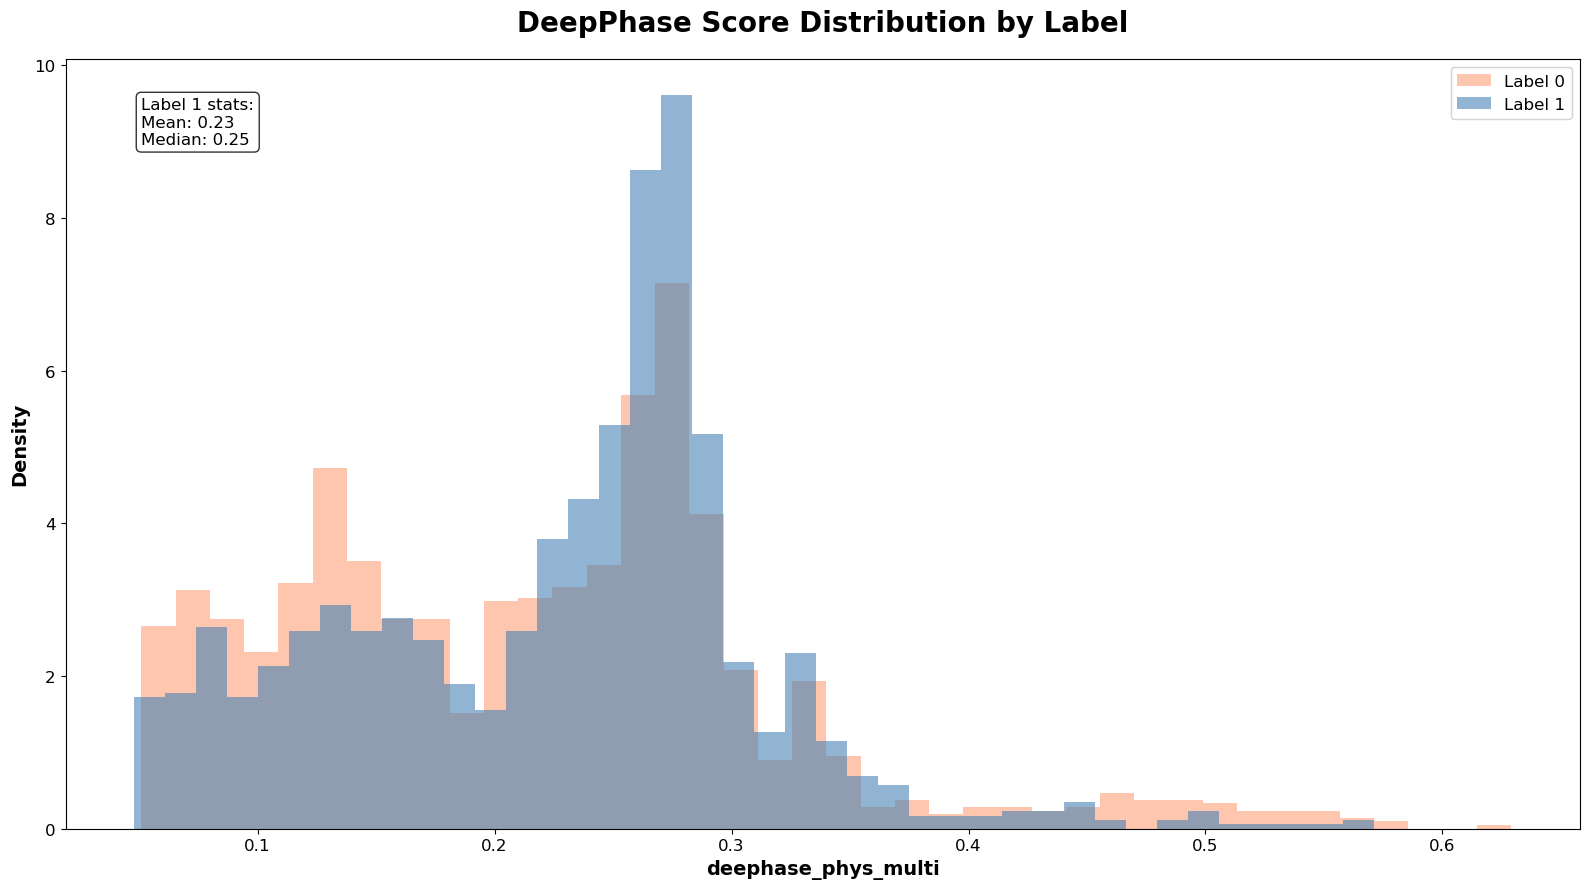

In [57]:
plot_deepphase_score_by_label(training_dataset_df, score_col="deephase_phys_multi")

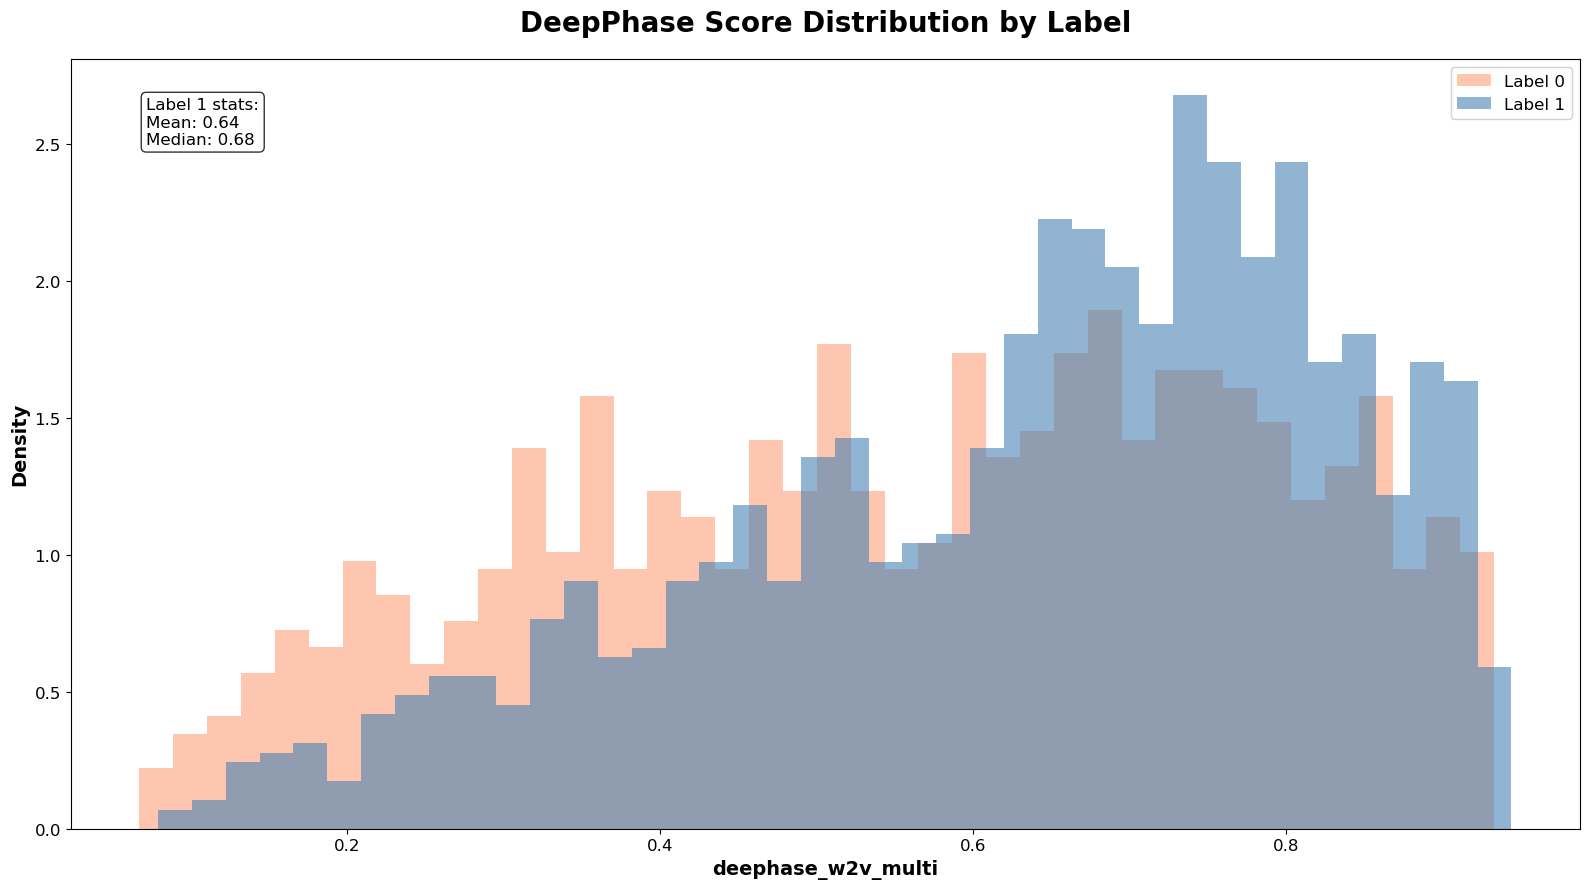

In [58]:
plot_deepphase_score_by_label(training_dataset_df, "deephase_w2v_multi")

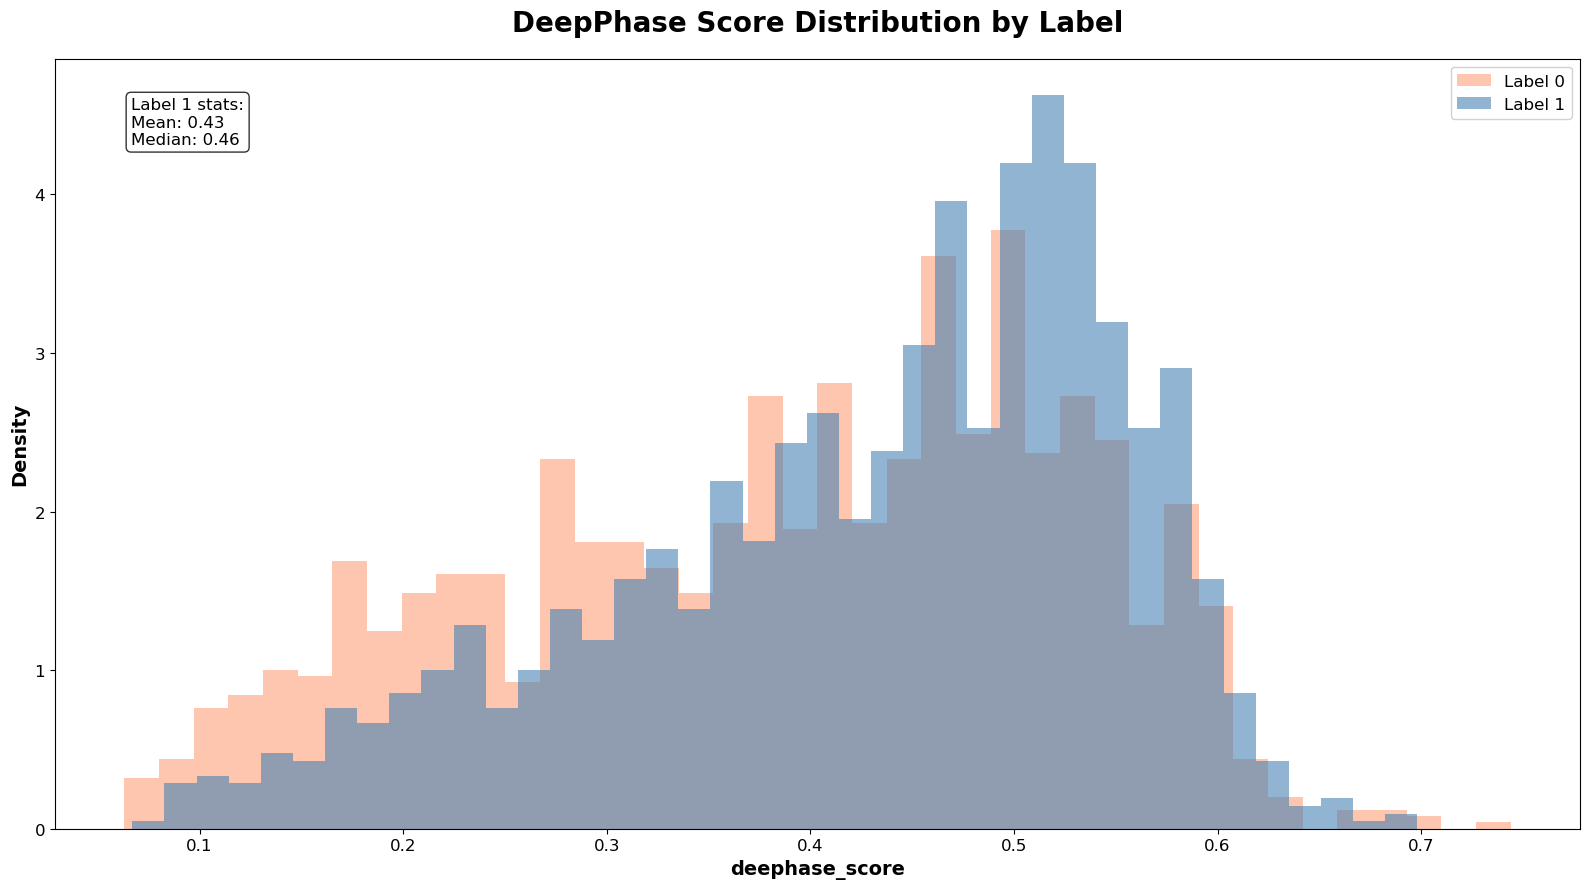

In [59]:
plot_deepphase_score_by_label(training_dataset_df, "deephase_score")

task 41: feature importance and its contribution were
further analyzed to find which feature was more valuable for
the model performance after feature selection 

In [60]:
# Prefixes for PLM features
plm_prefixes = (
    'esm_protein_embedding_',
    'esm_residue_embedding_',
    'ptmmamba_residue_embedding_',
    'ptmmamba_protein_embedding_'
)

# Identify PLM and Biological features
plm_features = [feature for feature in total_selected_features if feature.startswith(plm_prefixes)]
bio_features = [feature for feature in total_selected_features if not feature.startswith(plm_prefixes)]

# Counts
plm_count = len(plm_features)
bio_count = len(bio_features)

# Output
print(f"total features number: ({len(total_selected_features)})")
print(f"PLM features ({plm_count}): {plm_features}")
print(f"Biological features ({bio_count}): {bio_features}")

print(f"PLM features: {plm_count}")
print(f"Biological features: {bio_count}")

total features number: (735)
PLM features (728): ['esm_residue_embedding_482', 'ptmmamba_residue_embedding_190', 'esm_residue_embedding_1069', 'esm_residue_embedding_328', 'esm_residue_embedding_604', 'esm_protein_embedding_1159', 'esm_residue_embedding_311', 'esm_residue_embedding_110', 'esm_residue_embedding_751', 'esm_residue_embedding_1074', 'ptmmamba_residue_embedding_599', 'esm_residue_embedding_349', 'ptmmamba_protein_embedding_position_746', 'esm_residue_embedding_621', 'esm_residue_embedding_384', 'esm_protein_embedding_1080', 'esm_residue_embedding_109', 'esm_residue_embedding_1054', 'esm_residue_embedding_437', 'esm_residue_embedding_945', 'esm_protein_embedding_1072', 'esm_residue_embedding_902', 'esm_residue_embedding_565', 'esm_residue_embedding_48', 'ptmmamba_residue_embedding_262', 'esm_residue_embedding_357', 'esm_residue_embedding_342', 'esm_protein_embedding_922', 'esm_residue_embedding_299', 'esm_residue_embedding_966', 'esm_residue_embedding_1228', 'ptmmamba_protei

### 4.4	Prediction performance with different classifiers

task 42: To test the validity of the optimal feature set in different classifiers, three common classifiers were used to predict 14-3-3 sites: random forest (RF), XGBoost (XGB), SVM and ANN are used. 

In [77]:
# !pip install xgboost

In [182]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

classifer_lst = [RandomForestClassifier(max_depth=7,random_state=42), 
                 XGBClassifier(max_depth=3, n_estimators=1000, random_state=42,gamma=0.1,reg_alpha=0.1,reg_lambda=1.0,), 
                 SVC(random_state=42), 
                 MLPClassifier(random_state=42)]

In [183]:
def convert_text_file_to_list(file_path):
    """
    Reads a text file and converts its content into a list.
    
    Args:
        file_path: Path to the text file
        
    Returns:
        A list containing the items from the text file
    """
    try:
        with open(file_path, 'r') as file:
            # Read the content and remove any trailing separators
            content = file.read().strip()
            
            # Split the content by commas if they exist, otherwise by spaces or dashes
            if ',' in content:
                items = content.split(',')
            elif '-------------------' in content:
                # Split by the separator
                items = content.split('-------------------')[0].split()
            else:
                items = content.split()
            
            # Clean up each item (remove extra whitespace)
            items = [item.strip() for item in items if item.strip()]
            
            return items
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return []
    except Exception as e:
        print(f"Error: {e}")
        return []

In [184]:
total_feature_file_path = "total_selected_features.txt"
bio_plm_features = convert_text_file_to_list(total_feature_file_path)

bio_feature_file_path = "biology_selected_features.txt"
bio_features = convert_text_file_to_list(bio_feature_file_path)

In [185]:
mrmr_bio_features = ['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'iupred_score', 'onehot_4_L', 'onehot_-3_S', 'onehot_-4_R', 'onehot_-2_G', 'onehot_1_P', 'onehot_-3_V', 'onehot_-2_R', 'onehot_2_K', 'onehot_-3_D', 'onehot_1_R', 'onehot_-3_G', 'onehot_-1_H', 'onehot_-3_A', 'onehot_-5_R', 'nuSVR', 'onehot_3_D', 'onehot_-3_L', 'onehot_-3_N', 'onehot_-3_P', 'deephase_w2v_multi', 'onehot_7_G', 'NCPR']
mrmr_bio_plm_features =['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491', 'esm_residue_embedding_1259', 'esm_residue_embedding_394', 'esm_residue_embedding_1215', 'esm_residue_embedding_53', 'esm_residue_embedding_546', 'esm_residue_embedding_356', 'esm_residue_embedding_197', 'esm_residue_embedding_327', 'esm_residue_embedding_385', 'esm_residue_embedding_453', 'esm_protein_embedding_68', 'esm_residue_embedding_1242', 'esm_residue_embedding_482', 'esm_residue_embedding_844', 'esm_residue_embedding_1074']
mrmr_all_features = list(set(mrmr_bio_features+mrmr_bio_plm_features))

In [186]:
mrmr_all_features

['esm_residue_embedding_482',
 'esm_residue_embedding_197',
 'esm_residue_embedding_844',
 'onehot_1_L',
 'onehot_-3_G',
 'esm_residue_embedding_715',
 'onehot_-3_A',
 'esm_residue_embedding_1259',
 'ptmmamba_residue_embedding_79',
 'esm_residue_embedding_1074',
 'iupred_score',
 'onehot_-3_L',
 'esm_residue_embedding_53',
 'esm_residue_embedding_453',
 'onehot_1_P',
 'onehot_-3_R',
 'onehot_-1_H',
 'onehot_1_R',
 'esm_residue_embedding_327',
 'onehot_-3_P',
 'phospho_score',
 'esm_residue_embedding_1041',
 'onehot_-1_K',
 'onehot_-3_E',
 'onehot_7_G',
 'onehot_-4_R',
 'esm_residue_embedding_394',
 'ptmmamba_residue_embedding_408',
 'onehot_4_L',
 'onehot_2_P',
 'NCPR',
 'esm_residue_embedding_546',
 'onehot_-2_G',
 'esm_residue_embedding_491',
 'esm_residue_embedding_1215',
 'onehot_2_K',
 'onehot_-3_N',
 'onehot_-2_S',
 'esm_residue_embedding_81',
 'onehot_-3_V',
 'onehot_-5_R',
 'onehot_3_D',
 'esm_protein_embedding_68',
 'nuSVR',
 'esm_residue_embedding_356',
 'onehot_-2_R',
 'esm_

In [187]:
bio_plm_features

['esm_residue_embedding_482',
 'ptmmamba_residue_embedding_190',
 'esm_residue_embedding_1069',
 'esm_residue_embedding_328',
 'esm_residue_embedding_604',
 'esm_protein_embedding_1159',
 'esm_residue_embedding_311',
 'esm_residue_embedding_110',
 'esm_residue_embedding_751',
 'esm_residue_embedding_1074',
 'ptmmamba_residue_embedding_599',
 'esm_residue_embedding_349',
 'ptmmamba_protein_embedding_position_746',
 'esm_residue_embedding_621',
 'esm_residue_embedding_384',
 'esm_protein_embedding_1080',
 'esm_residue_embedding_109',
 'onehot_-3_R',
 'esm_residue_embedding_1054',
 'esm_residue_embedding_437',
 'esm_residue_embedding_945',
 'esm_protein_embedding_1072',
 'esm_residue_embedding_902',
 'esm_residue_embedding_565',
 'esm_residue_embedding_48',
 'ptmmamba_residue_embedding_262',
 'esm_residue_embedding_357',
 'esm_residue_embedding_342',
 'esm_protein_embedding_922',
 'esm_residue_embedding_299',
 'esm_residue_embedding_966',
 'esm_residue_embedding_1228',
 'ptmmamba_protein_

In [188]:
bio_features

['onehot_1_P',
 'onehot_-3_R',
 'onehot_2_P',
 'NCPR',
 'fK',
 'nuSVR',
 'onehot_-2_R',
 'phospho_score',
 'SCD',
 'iupred_score',
 'faro',
 'deephase_w2v_multi',
 'onehot_-3_E',
 'kappa',
 'onehot_-2_S',
 'onehot_-4_R']

In [189]:
bio_plm_features = bio_plm_features + ["label", "augmentated from uniprot ID"]
bio_features = bio_features + ["label", "augmentated from uniprot ID"]
mrmr_all_features = mrmr_all_features + ["label", "augmentated from uniprot ID"]

training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]

In [190]:
len(bio_plm_features)

737

In [191]:
len(bio_features)

18

In [192]:
print("model selection for bio and plm features")
for model in classifer_lst:
    train(training_dataset_df[bio_plm_features], model)

model selection for bio and plm features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7, random_state=42) Performance Metrics:

Training Data Metrics:
Accuracy: 0.97
MCC: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       966
           1       0.96      0.97      0.97       841

    accuracy                           0.97      1807
   macro avg       0.97      0.97      0.97      1807
weighted avg       0.97      0.97      0.97      1807


Test Data Metrics:
Accuracy: 0.80
MCC: 0.61
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.92      0.82       233
           1       0.89      0.68      0.77       226

    accuracy                           0.80       459
   macro avg       0.82      0.80      0.80 

In [193]:
print("model selection for bio only features")
for model in classifer_lst:
    train(training_dataset_df[bio_features], model)

model selection for bio only features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7, random_state=42) Performance Metrics:

Training Data Metrics:
Accuracy: 0.90
MCC: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       966
           1       0.88      0.91      0.89       841

    accuracy                           0.90      1807
   macro avg       0.90      0.90      0.90      1807
weighted avg       0.90      0.90      0.90      1807


Test Data Metrics:
Accuracy: 0.83
MCC: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       233
           1       0.84      0.80      0.82       226

    accuracy                           0.83       459
   macro avg       0.83      0.83      0.83    

In [194]:
print("model selection for mrmr features")
for model in classifer_lst:
    train(training_dataset_df[mrmr_all_features], model)

model selection for mrmr features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7, random_state=42) Performance Metrics:

Training Data Metrics:
Accuracy: 0.93
MCC: 0.86
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       966
           1       0.92      0.94      0.93       841

    accuracy                           0.93      1807
   macro avg       0.93      0.93      0.93      1807
weighted avg       0.93      0.93      0.93      1807


Test Data Metrics:
Accuracy: 0.87
MCC: 0.74
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       233
           1       0.89      0.83      0.86       226

    accuracy                           0.87       459
   macro avg       0.87      0.87      0.87       4

## final selection of the features using REFCV

In [195]:
import numpy as np
import pandas as pd
from sklearn.model_selection import BaseCrossValidator

class StratifiedGroupKFold(BaseCrossValidator):
    def __init__(self, n_splits=5, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
        
    def split(self, X, y, groups):
        if isinstance(groups, np.ndarray):
            groups = pd.Series(groups)

        # Create a DataFrame containing labels and groups
        df = pd.DataFrame({'label': y, 'group': groups})
        
        # Calculate group counts and assign labels
        group_to_label = df.groupby('group')['label'].first().to_dict()
        group_counts = df.groupby('group').size().to_dict()
        
        labels, label_counts = np.unique(y, return_counts=True)
        rng = np.random.RandomState(self.random_state)

        # Split groups by label
        label_group_split = {label: [] for label in labels}
        for label, group in group_to_label.items():
            label_group_split[group].append(label)
        
        for label in labels:
            if self.shuffle:
                rng.shuffle(label_group_split[label])
        
        # Distribute groups into folds
        fold_splits = [{'groups': [], 'count': 0} for _ in range(self.n_splits)]
        for label in labels:
            for group in label_group_split[label]:
                fold_idx = np.argmin([f['count'] for f in fold_splits])
                fold_splits[fold_idx]['groups'].append(group)
                fold_splits[fold_idx]['count'] += group_counts[group]

        # Yield the train and test indices
        indices = np.arange(len(X))
        for fold in fold_splits:
            test_mask = groups.isin(fold['groups'])
            test_indices = indices[test_mask]
            train_indices = indices[~test_mask]
            yield train_indices, test_indices

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [196]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score, make_scorer

# Load your dataset
df = pd.read_pickle("final_dataset_with_all_new.pkl")

features = mrmr_all_features

# Select the correct features and the target variable
df = df[df["usage"] == "training"][features].reset_index(drop=True)
target = "label"
used_features = df.columns.drop(target)
X = df[used_features]
y = df[target]

# Proceed with splitting
X_train, X_valid, y_train, y_valid = balanced_group_train_test_split(
    X,
    y,
    group_col='augmentated from uniprot ID',
    test_size=0.2,
    random_state=42, 
    drop_group_col=False
)

# Assign group labels
group_col = "augmentated from uniprot ID"
groups = X_train[group_col].values
X_train = X_train.drop(columns=[group_col])

# Initialize the Random Forest model
# model = RandomForestClassifier(max_depth=7, random_state=42)
model = XGBClassifier(max_depth=3, n_estimators=1000, random_state=42,gamma=0.1,reg_alpha=0.1,reg_lambda=1.0,)

# Create a scoring function for AUC
auc_scorer = make_scorer(roc_auc_score, greater_is_better=True, needs_proba=True)

# Use the customized cross-validator
custom_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RFECV with the Random Forest model and AUC scoring
rfe_cv = RFECV(
    estimator=model,
    step=1,
    cv=custom_cv,
    scoring=auc_scorer,
    min_features_to_select=25, verbose=2
)

# Fit RFECV to the training data
rfe_cv.fit(X_train, y_train, groups=groups)

Fitting estimator with 52 features.
Fitting estimator with 51 features.
Fitting estimator with 50 features.
Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 52 fe

RFECV(cv=StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True),
      estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=0.1, grow_policy=None,
                              importance_type=N...
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                 

In [197]:
optimal_features_mask = rfe_cv.support_
optimal_features = X_train.columns[optimal_features_mask]

print("Optimal number of features:", rfe_cv.n_features_)
print("Selected Features:", list(optimal_features))

Optimal number of features: 40
Selected Features: ['esm_residue_embedding_482', 'esm_residue_embedding_197', 'esm_residue_embedding_844', 'onehot_1_L', 'esm_residue_embedding_715', 'esm_residue_embedding_1259', 'ptmmamba_residue_embedding_79', 'esm_residue_embedding_1074', 'iupred_score', 'esm_residue_embedding_53', 'onehot_1_P', 'onehot_-3_R', 'onehot_-1_H', 'onehot_1_R', 'esm_residue_embedding_327', 'phospho_score', 'esm_residue_embedding_1041', 'onehot_-1_K', 'onehot_-3_E', 'onehot_7_G', 'onehot_-4_R', 'esm_residue_embedding_394', 'ptmmamba_residue_embedding_408', 'onehot_2_P', 'esm_residue_embedding_546', 'onehot_-2_G', 'esm_residue_embedding_491', 'esm_residue_embedding_1215', 'onehot_-2_S', 'esm_residue_embedding_81', 'onehot_-5_R', 'onehot_3_D', 'esm_protein_embedding_68', 'nuSVR', 'esm_residue_embedding_356', 'onehot_-2_R', 'esm_residue_embedding_385', 'esm_residue_embedding_1171', 'deephase_w2v_multi', 'esm_residue_embedding_1242']


In [198]:
# Transform datasets to include only selected features
X_train_selected = rfe_cv.transform(X_train)
X_valid_selected = rfe_cv.transform(X_valid.drop(columns=[group_col]))

# Re-fit model with selected features
model.fit(X_train_selected, y_train)

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report,
    matthews_corrcoef
)

# Use the trained model to predict on the validation set
y_pred_proba = model.predict_proba(X_valid_selected)[:, 1]  # Probabilities
y_pred = model.predict(X_valid_selected)  # Class labels

# Calculate AUC score
roc_auc = roc_auc_score(y_valid, y_pred_proba)
print(f"AUC: {roc_auc:.2f}")

# Calculate other performance metrics
accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Calculate Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_valid, y_pred)
print(f"Matthews Correlation Coefficient: {mcc:.2f}")

# Display confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Detailed classification report
print("Classification Report:")
print(classification_report(y_valid, y_pred))

AUC: 0.93
Accuracy: 0.86
Precision: 0.89
Recall: 0.83
F1 Score: 0.86
Matthews Correlation Coefficient: 0.73
Confusion Matrix:
[[209  24]
 [ 39 187]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       233
           1       0.89      0.83      0.86       226

    accuracy                           0.86       459
   macro avg       0.86      0.86      0.86       459
weighted avg       0.86      0.86      0.86       459



## 4.5	Model architecture and optimization 

task 43: fine-tuned certain hyperparameters (Table X) of the model

In [12]:
optimal_features = ['esm_residue_embedding_482', 'esm_residue_embedding_197', 'esm_residue_embedding_844', 'onehot_1_L', 'esm_residue_embedding_715', 'esm_residue_embedding_1259', 'ptmmamba_residue_embedding_79', 'esm_residue_embedding_1074', 'iupred_score', 'esm_residue_embedding_53', 'onehot_1_P', 'onehot_-3_R', 'onehot_-1_H', 'onehot_1_R', 'esm_residue_embedding_327', 'phospho_score', 'esm_residue_embedding_1041', 'onehot_-1_K', 'onehot_-3_E', 'onehot_7_G', 'onehot_-4_R', 'esm_residue_embedding_394', 'ptmmamba_residue_embedding_408', 'onehot_2_P', 'esm_residue_embedding_546', 'onehot_-2_G', 'esm_residue_embedding_491', 'esm_residue_embedding_1215', 'onehot_-2_S', 'esm_residue_embedding_81', 'onehot_-5_R', 'onehot_3_D', 'esm_protein_embedding_68', 'nuSVR', 'esm_residue_embedding_356', 'onehot_-2_R', 'esm_residue_embedding_385', 'esm_residue_embedding_1171', 'deephase_w2v_multi', 'esm_residue_embedding_1242']
df = pd.read_pickle("final_dataset_with_all_new.pkl")
features = optimal_features + ["label", "augmentated from uniprot ID"]

In [13]:
# a custormized CV for gridsearch and REFCV
import numpy as np
from sklearn.model_selection import BaseCrossValidator

class StratifiedGroupKFold(BaseCrossValidator):
    """
    Stratified Group K-Fold cross-validator.
    Splits data into folds preserving class distribution while keeping groups intact.
    """
    def __init__(self, n_splits=5, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X, y, groups):
        labels, label_counts = np.unique(y, return_counts=True)
        group_to_label = {group: y[idx[0]] for group, idx in X.groupby(groups).groups.items()}
        group_counts = X.groupby(groups).size()
        rng = np.random.RandomState(self.random_state)

        # Split groups by label
        label_group_split = {}
        for label in labels:
            label_groups = [g for g in groups.unique() if group_to_label[g] == label]
            if self.shuffle:
                rng.shuffle(label_groups)
            label_group_split[label] = label_groups

        # Distribute groups into folds
        fold_splits = [{'groups': [], 'count': 0} for _ in range(self.n_splits)]
        for label in labels:
            target_per_fold = label_counts[label] // self.n_splits
            for group in label_group_split[label]:
                group_size = group_counts[group]
                fold_idx = np.argmin([f['count'] for f in fold_splits])
                fold_splits[fold_idx]['groups'].append(group)
                fold_splits[fold_idx]['count'] += group_size

        # Generate indices for splits
        for fold in fold_splits:
            test_mask = groups.isin(fold['groups'])
            test_indices = X[test_mask].index
            train_indices = X[~test_mask].index
            yield (train_indices, test_indices)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [14]:
# After loading the DataFrame and filtering
df = df[df["usage"] == "training"][features].reset_index(drop=True)  # Reset index here
y = df["label"]
target = "label"
used_features = list(df.columns)
used_features.remove(target)
x = df[used_features]

# Proceed with splitting
X_train, X_valid, y_train, y_valid = balanced_group_train_test_split(
    x,
    y,
    group_col='augmentated from uniprot ID',
    test_size=0.2,
    random_state=42, 
    drop_group_col=False
)

# Reset indices of the split DataFrames
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Now assign groups and drop the group column
group_col = "augmentated from uniprot ID"
groups = X_train[group_col]
X_train = X_train.drop(columns=[group_col])

In [15]:
X_train.head(2)

,esm_residue_embedding_482,esm_residue_embedding_197,esm_residue_embedding_844,onehot_1_L,esm_residue_embedding_715,esm_residue_embedding_1259,ptmmamba_residue_embedding_79,esm_residue_embedding_1074,iupred_score,esm_residue_embedding_53,...,onehot_-5_R,onehot_3_D,esm_protein_embedding_68,nuSVR,esm_residue_embedding_356,onehot_-2_R,esm_residue_embedding_385,esm_residue_embedding_1171,deephase_w2v_multi,esm_residue_embedding_1242
0,-0.229821,0.115728,0.076547,0.0,-0.178075,-0.241583,1.531378,-0.342021,0.541878,0.189046,...,0.0,1.0,0.005706,0.556,-0.124178,0.0,-0.228879,0.267552,0.160,0.108347
1,-0.226443,0.120560,0.036033,0.0,-0.173061,-0.169055,1.268627,-0.423211,0.509769,0.138703,...,0.0,1.0,0.048106,0.732,-0.138242,0.0,-0.218638,0.274188,0.173,0.127299
2,-0.241060,0.122229,0.006990,0.0,-0.083031,-0.171437,-0.094250,-0.162433,0.465241,0.071787,...,0.0,1.0,0.046186,0.000,-0.072810,0.0,-0.249030,0.174640,0.129,-0.028194
3,-0.170375,0.096526,0.072166,0.0,-0.135232,-0.244515,0.907481,-0.424838,0.566480,0.256448,...,0.0,1.0,0.101362,0.552,-0.223588,0.0,-0.256033,0.282219,0.352,0.161024
4,-0.334085,0.221625,0.180982,0.0,-0.263075,-0.319071,0.408285,-0.106872,0.837511,0.170396,...,0.0,0.0,0.056559,0.570,-0.040749,0.0,-0.267319,0.202958,0.742,0.018206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1802,-0.136135,0.126113,-0.135277,0.0,-0.012335,0.005391,-0.179280,0.033765,0.703578,0.036241,...,0.0,0.0,0.023764,0.503,0.091071,0.0,-0.191771,0.184116,0.699,-0.028443
1803,-0.141047,0.098873,-0.100147,0.0,0.318119,0.055398,0.447150,-0.141686,0.798249,-0.040832,...,0.0,0.0,0.057012,0.568,-0.017660,0.0,-0.062217,0.149462,0.774,-0.361325
1804,-0.188040,-0.040502,-0.086630,0.0,0.013142,0.130471,0.837121,0.088175,0.831250,0.039237,...,0.0,0.0,0.029800,0.609,0.102250,0.0,0.137874,-0.100676,0.776,-0.079866
1805,-0.142337,0.453082,-0.027795,1.0,-0.030406,0.046780,0.213626,-0.274073,0.566480,-0.246281,...,0.0,0.0,0.100034,0.587,0.010574,0.0,-0.025808,0.353010,0.726,-0.218823


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Define model and hyperparameters
steps = [('classifier', XGBClassifier(tree_method= 'gpu_hist',random_state=42))]
pipe = Pipeline(steps)

scorer = make_scorer(average_precision_score)

param_grid = {
    'classifier__n_estimators': [100, 300, 500, 1000],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2,3,4],
    'classifier__gamma': [0, 0.1, 0.5],
    'classifier__reg_alpha': [0, 0.1, 0.5],
    'classifier__reg_lambda': [0, 0.5, 1]
}

# param_grid = {
# {'classifier__gamma': 0.5,
#  'classifier__learning_rate': 0.05,
#  'classifier__max_depth': 4,
#  'classifier__n_estimators': 100,
#  'classifier__reg_alpha': 0.5,
#  'classifier__reg_lambda': 0.5}

# Initialize GridSearchCV with custom CV
custom_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
model_gsv = GridSearchCV(pipe, param_grid, cv=custom_cv, scoring = scorer, n_jobs=-1, verbose=2)

# Fit with groups
model_gsv = model_gsv.fit(X_train, y_train, groups=groups)
model_gsv.best_params_
best_xgboost_model = model_gsv.best_estimator_

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


H:\anaconda3\envs\1433predictor20250101\lib\site-packages\xgboost\core.py:158: UserWarning: [11:24:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


In [17]:
model_gsv.best_params_

# {'classifier__gamma': 0.5,
#  'classifier__learning_rate': 0.05,
#  'classifier__max_depth': 4,
#  'classifier__n_estimators': 100,
#  'classifier__reg_alpha': 0.5,
#  'classifier__reg_lambda': 0.5}

{'classifier__gamma': 0.5,
 'classifier__learning_rate': 0.05,
 'classifier__max_depth': 4,
 'classifier__n_estimators': 100,
 'classifier__reg_alpha': 0.5,
 'classifier__reg_lambda': 0.5}

In [19]:
# Evaluate the best model on the test set
from sklearn.metrics import matthews_corrcoef

# Training set evaluation
y_train_proba = best_xgboost_model.predict_proba(X_train)[:, 1]
y_train_pred = best_xgboost_model.predict(X_train)
train_mcc = matthews_corrcoef(y_train, y_train_pred)
model_classification_report = classification_report(y_train, y_train_pred)

# Validation set evaluation
if "augmentated from uniprot ID" in X_valid.columns:
    X_valid = X_valid.drop(columns=[group_col])
y_valid_proba = best_xgboost_model.predict_proba(X_valid)[:, 1]
y_valid_pred = best_xgboost_model.predict(X_valid)
valid_mcc = matthews_corrcoef(y_valid, y_valid_pred)
model_classification_report_valid = classification_report(y_valid, y_valid_pred)

# Print evaluation results
print("XGBoost Model")
print("Training performance:")
print(f"Average Precision Score: {average_precision_score(y_train, y_train_proba):.3e}")
print(f"Matthews Correlation Coefficient: {train_mcc:.3f}")
print(f"Classification Report (Training data):")
print(model_classification_report)
print("-" * 50)

print("Validation performance:")
print(f"Average Precision Score: {average_precision_score(y_valid, y_valid_proba):.3e}")
print(f"Matthews Correlation Coefficient: {valid_mcc:.3f}")
print(f"Classification Report (Validation data):")
print(model_classification_report_valid)
print("-" * 50)

XGBoost Model
Training performance:
Average Precision Score: 9.817e-01
Matthews Correlation Coefficient: 0.866
Classification Report (Training data):
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       966
           1       0.92      0.94      0.93       841

    accuracy                           0.93      1807
   macro avg       0.93      0.93      0.93      1807
weighted avg       0.93      0.93      0.93      1807

--------------------------------------------------
Validation performance:
Average Precision Score: 9.341e-01
Matthews Correlation Coefficient: 0.739
Classification Report (Validation data):
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       233
           1       0.88      0.85      0.86       226

    accuracy                           0.87       459
   macro avg       0.87      0.87      0.87       459
weighted avg       0.87      0.87      0.87       459

-----

H:\anaconda3\envs\1433predictor20250101\lib\site-packages\xgboost\core.py:158: UserWarning: [11:24:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
H:\anaconda3\envs\1433predictor20250101\lib\site-packages\xgboost\core.py:158: UserWarning: [11:24:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.


## 4.6 Feature Importance analysis

task 44: we conducted a thorough examination of feature importance using SHAP (SHapley Additive exPlanations) values

In [20]:
best_model = best_xgboost_model

In [21]:
# Get the feature importances from the XGBClassifier
feature_importances = best_model.named_steps['classifier'].feature_importances_

# Use the original feature names from your training data
feature_names = X_train.columns.tolist()  # Convert to list if needed

# Make sure the number of feature names matches the number of importance scores
if len(feature_names) == len(feature_importances):
    # Create a DataFrame to pair feature names with importance scores
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    
    # Sort by importance (descending)
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # Display the top 20 most important features
    print("Top most important features:")
    print(feature_importance_df[:50])
else:
    print(f"Warning: Number of feature names ({len(feature_names)}) doesn't match number of importance scores ({len(feature_importances)})")

Top 20 most important features:
                           Feature  Importance
11                     onehot_-3_R    0.388691
23                      onehot_2_P    0.055377
2        esm_residue_embedding_844    0.028385
28                     onehot_-2_S    0.023337
34       esm_residue_embedding_356    0.021811
36       esm_residue_embedding_385    0.021374
20                     onehot_-4_R    0.021371
15                   phospho_score    0.020420
35                     onehot_-2_R    0.019786
37      esm_residue_embedding_1171    0.017883
31                      onehot_3_D    0.017712
14       esm_residue_embedding_327    0.017098
6    ptmmamba_residue_embedding_79    0.017071
30                     onehot_-5_R    0.016991
5       esm_residue_embedding_1259    0.016867
27      esm_residue_embedding_1215    0.016585
16      esm_residue_embedding_1041    0.016524
24       esm_residue_embedding_546    0.016428
3                       onehot_1_L    0.015632
10                      oneh

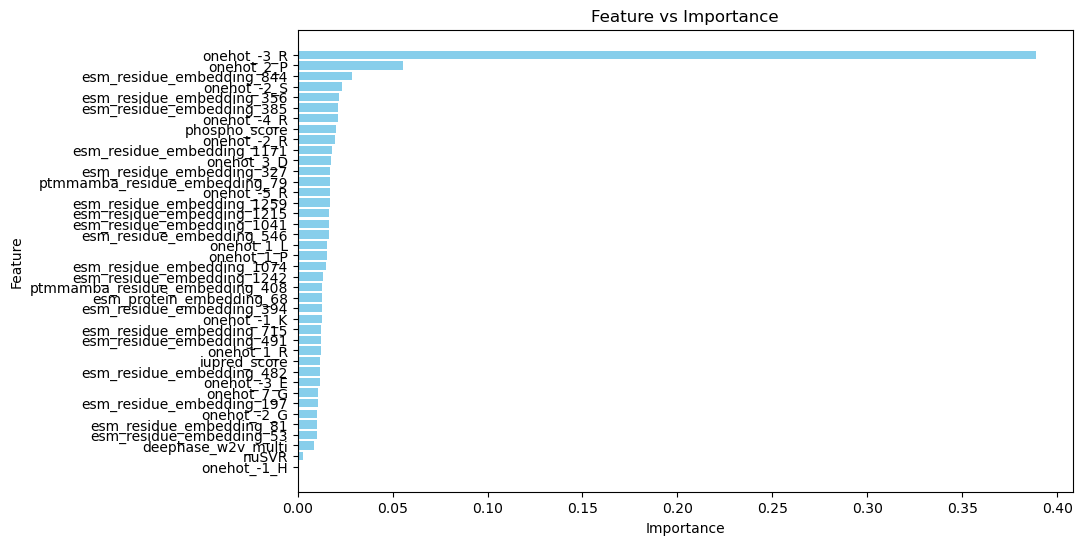

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Sorting the DataFrame based on the 'Value' column in descending order
df_sorted = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plotting the data
plt.figure(figsize=(10, 6))  # Set the figure size
plt.barh(df_sorted.iloc[:, 0], df_sorted.iloc[:, 1], color='skyblue')  # Create a horizontal bar plot

# Adding title and labels
plt.title('Feature vs Importance')
plt.ylabel(df_sorted.columns[0])
plt.xlabel(df_sorted.columns[1])

# Display the plot
plt.show()

In [26]:
# !pip install shap

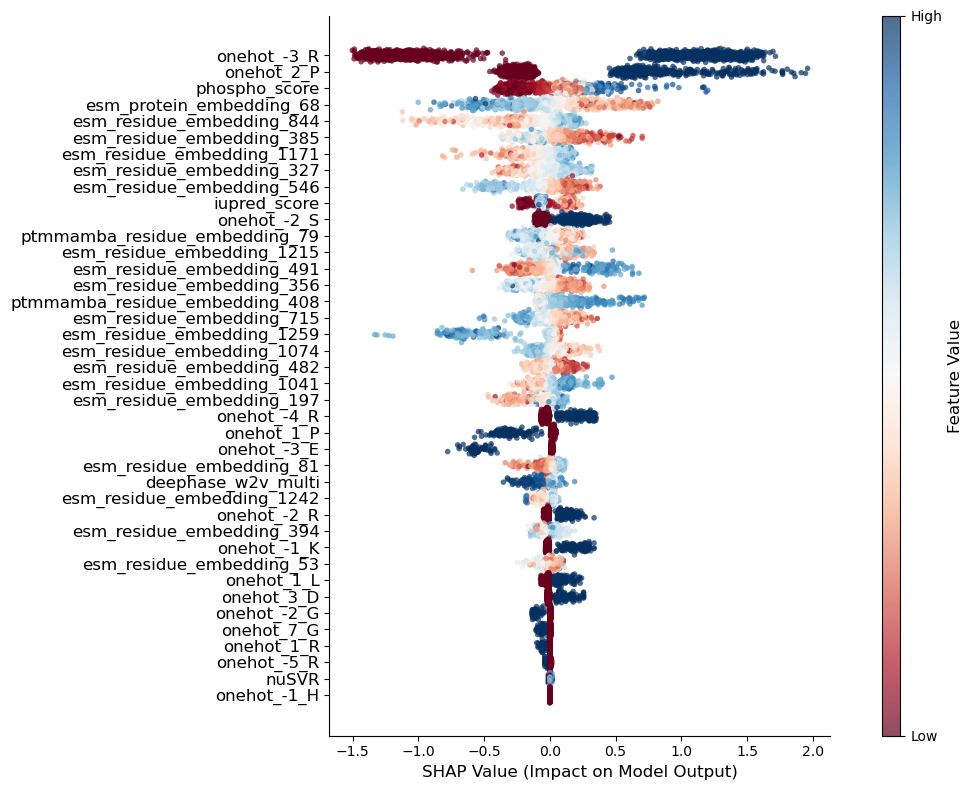

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import shap

def custom_beeswarm(shap_values, feature_names):
    # Extract values/data from Explanation object
    if isinstance(shap_values, shap.Explanation):
        shap_data = shap_values.data  # Original feature values
        shap_values = shap_values.values  # SHAP values
    
    # Ensure 2D array format
    if len(shap_values.shape) == 1:
        shap_values = shap_values.reshape(1, -1)
        shap_data = shap_data.reshape(1, -1)
    
    # Calculate feature importance (mean absolute SHAP)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    feature_order = np.argsort(mean_abs_shap)[::-1]  # Most important first
    
    # Create plot
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    
    # Plot each feature
    for y_pos, feature_idx in enumerate(feature_order):
        # Get SHAP values and original feature values
        shaps = shap_values[:, feature_idx]
        vals = shap_data[:, feature_idx]
        
        # Normalize feature values for coloring [0,1]
        if np.nanmin(vals) == np.nanmax(vals):
            colors = np.zeros_like(vals)
        else:
            colors = (vals - np.nanmin(vals)) / (np.nanmax(vals) - np.nanmin(vals))
        
        # Create jittered y positions
        jitter = np.random.normal(loc=y_pos, scale=0.15, size=len(shaps))
        
        # Plot points with SHAP-style coloring (RdBu colormap)
        scatter = ax.scatter(
            x=shaps,
            y=jitter,
            c=colors,
            cmap=plt.cm.RdBu,  # SHAP's default colormap
            vmin=0,
            vmax=1,
            s=16,
            alpha=0.7,
            linewidth=0,
            rasterized=True
        )
    
    # Color bar (matching SHAP's style)
    cb = plt.colorbar(scatter, ax=ax, aspect=40, pad=0.08)
    cb.set_label('Feature Value', size=12)
    cb.set_ticks([0, 1])
    cb.set_ticklabels(['Low', 'High'])
    
    # Axis formatting (match SHAP's style)
    ax.set_yticks(np.arange(len(feature_order)))
    ax.set_yticklabels([feature_names[i] for i in feature_order], fontsize=12)
    ax.invert_yaxis()  # Most important at top
    ax.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=12)
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_label_position('bottom')
    
    # Remove spines and grid
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(False)
    
    plt.tight_layout()
    plt.show()

# Usage
custom_beeswarm(shap_values, feature_names)

In [27]:
import shap
xgboost_model = best_model.named_steps['classifier']
# print(type(random_forest_model))
# Create a SHAP explainer

# Create a SHAP explainer
explainer = shap.TreeExplainer(xgboost_model)

# Calculate SHAP values
shap_values = explainer(X_train[feature_names])

# Usage
custom_beeswarm(shap_values, feature_names)

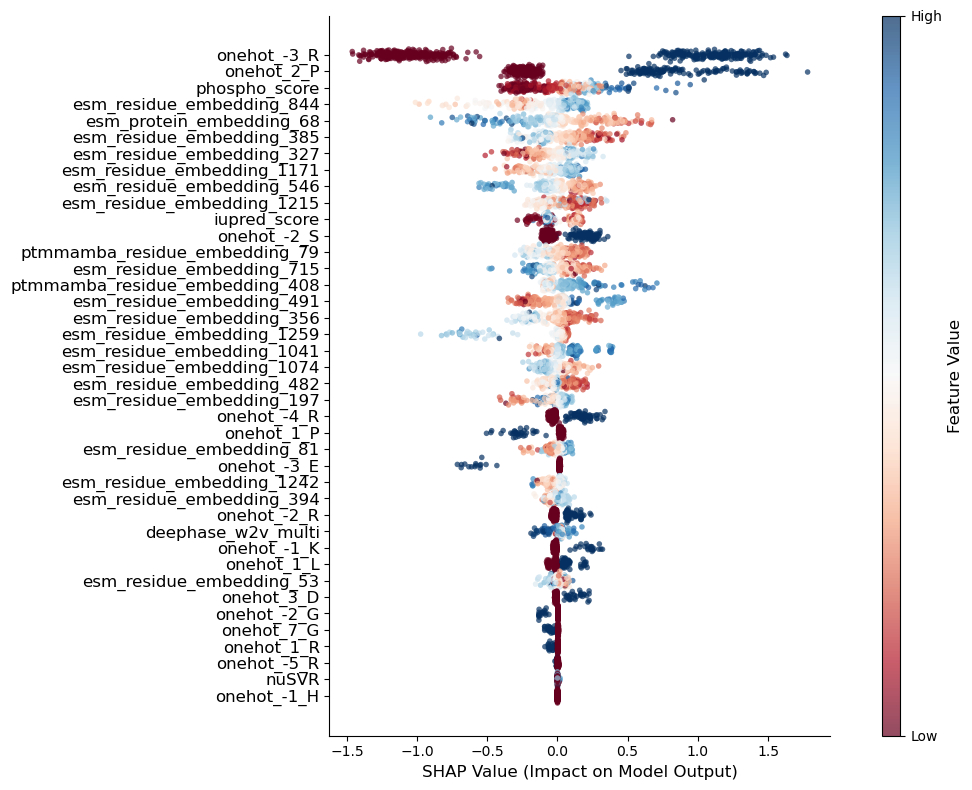

In [32]:
# for validate dataset 
# Calculate SHAP values
shap_values = explainer(X_valid[feature_names])

custom_beeswarm(shap_values, feature_names)

## 4.7	Performance evaluation and comparison with existing methods, Validation on independent test sets

task 46: Independent datset test with 14-3-3 pred and 14-3-3 site-finder, compare with our results.

In [ ]:
# retrain the 14-3-3 pred using onehot 

In [33]:
df = pd.read_pickle("final_dataset_with_all_new.pkl")

# After loading the DataFrame and filtering
df = df[df["usage"] == "training"].filter(regex=r'^(onehot_|label|augmentated from uniprot ID)').reset_index(drop=True)  # Reset index here
y = df["label"]
target = "label"
used_features = list(df.columns)
used_features.remove(target)
x = df[used_features]

# Proceed with splitting
X_train, X_valid, y_train, y_valid = balanced_group_train_test_split(
    x,
    y,
    group_col='augmentated from uniprot ID',
    test_size=0.2,
    random_state=42, 
    drop_group_col=False
)

# Reset indices of the split DataFrames
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Now assign groups and drop the group column
group_col = "augmentated from uniprot ID"
groups = X_train[group_col]
X_train = X_train.drop(columns=[group_col])


from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Define model and hyperparameters
steps = [('classifier', XGBClassifier(tree_method= 'gpu_hist',random_state=42))]
pipe = Pipeline(steps)

scorer = make_scorer(average_precision_score)

param_grid = {
    'classifier__n_estimators': [100, 300, 500, 1000],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2,3,4],
    'classifier__gamma': [0, 0.1, 0.5],
    'classifier__reg_alpha': [0, 0.1, 0.5],
    'classifier__reg_lambda': [0, 0.5, 1]
}

# Initialize GridSearchCV with custom CV
custom_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
model_gsv = GridSearchCV(pipe, param_grid, cv=custom_cv, scoring = scorer, n_jobs=-1, verbose=2)

# Fit with groups
model_gsv = model_gsv.fit(X_train, y_train, groups=groups)
model_gsv.best_params_
best_onehot_model = model_gsv.best_estimator_

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


H:\anaconda3\envs\1433predictor20250101\lib\site-packages\xgboost\core.py:158: UserWarning: [13:15:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


In [34]:
model_gsv.best_params_
# {'classifier__gamma': 0,
#  'classifier__learning_rate': 0.05,
#  'classifier__max_depth': 3,
#  'classifier__n_estimators': 500,
#  'classifier__reg_alpha': 0.5,
#  'classifier__reg_lambda': 0.5}

{'classifier__gamma': 0,
 'classifier__learning_rate': 0.05,
 'classifier__max_depth': 3,
 'classifier__n_estimators': 500,
 'classifier__reg_alpha': 0.5,
 'classifier__reg_lambda': 0.5}

In [36]:
# Evaluate the best model on the test set
from sklearn.metrics import matthews_corrcoef

# Training set evaluation
y_train_proba = best_onehot_model.predict_proba(X_train)[:, 1]
y_train_pred = best_onehot_model.predict(X_train)
train_mcc = matthews_corrcoef(y_train, y_train_pred)
model_classification_report = classification_report(y_train, y_train_pred)

# Validation set evaluation
if "augmentated from uniprot ID" in X_valid.columns:
    X_valid = X_valid.drop(columns=[group_col])
y_valid_proba = best_onehot_model.predict_proba(X_valid)[:, 1]
y_valid_pred = best_onehot_model.predict(X_valid)
valid_mcc = matthews_corrcoef(y_valid, y_valid_pred)
model_classification_report_valid = classification_report(y_valid, y_valid_pred)

# Print evaluation results
print("XGBoost Model trained by onehot features")
print("Training performance:")
print(f"Average Precision Score: {average_precision_score(y_train, y_train_proba):.3e}")
print(f"Matthews Correlation Coefficient: {train_mcc:.3f}")
print(f"Classification Report (Training data):")
print(model_classification_report)
print("-" * 50)

print("Validation performance:")
print(f"Average Precision Score: {average_precision_score(y_valid, y_valid_proba):.3e}")
print(f"Matthews Correlation Coefficient: {valid_mcc:.3f}")
print(f"Classification Report (Validation data):")
print(model_classification_report_valid)
print("-" * 50)

H:\anaconda3\envs\1433predictor20250101\lib\site-packages\xgboost\core.py:158: UserWarning: [13:20:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


XGBoost Model trained by onehot features
Training performance:
Average Precision Score: 9.892e-01
Matthews Correlation Coefficient: 0.888
Classification Report (Training data):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       966
           1       0.93      0.95      0.94       841

    accuracy                           0.94      1807
   macro avg       0.94      0.94      0.94      1807
weighted avg       0.94      0.94      0.94      1807

--------------------------------------------------
Validation performance:
Average Precision Score: 9.142e-01
Matthews Correlation Coefficient: 0.705
Classification Report (Validation data):
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       233
           1       0.87      0.82      0.84       226

    accuracy                           0.85       459
   macro avg       0.85      0.85      0.85       459
weighted avg       0.85      0.85

In [50]:
best_model = best_onehot_model
# Get the feature importances from the XGBClassifier
feature_importances = best_model.named_steps['classifier'].feature_importances_

# Use the original feature names from your training data
feature_names = X_train.columns.tolist()  # Convert to list if needed

# Make sure the number of feature names matches the number of importance scores
if len(feature_names) == len(feature_importances):
    # Create a DataFrame to pair feature names with importance scores
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    
    # Sort by importance (descending)
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # Display the top 20 most important features
    print("Top most important features:")
    print(feature_importance_df[:50])
else:
    print(f"Warning: Number of feature names ({len(feature_names)}) doesn't match number of importance scores ({len(feature_importances)})")

Top most important features:
         Feature  Importance
102  onehot_-3_R    0.098758
210   onehot_2_P    0.024188
119  onehot_-2_L    0.015979
80   onehot_-4_R    0.013339
30   onehot_-6_K    0.013334
222   onehot_3_D    0.012033
125  onehot_-2_S    0.011836
143  onehot_-1_N    0.010459
254   onehot_4_P    0.010381
26   onehot_-6_F    0.010260
188   onehot_1_P    0.010223
124  onehot_-2_R    0.010186
96   onehot_-3_K    0.010046
36   onehot_-6_R    0.010006
177   onehot_1_C    0.009556
3    onehot_-7_E    0.009504
144  onehot_-1_P    0.009495
81   onehot_-4_S    0.009157
148  onehot_-1_T    0.008805
176   onehot_1_A    0.008588
8    onehot_-7_K    0.008328
37   onehot_-6_S    0.008201
57   onehot_-5_Q    0.008198
301   onehot_6_S    0.008116
270   onehot_5_H    0.007944
190   onehot_1_R    0.007826
91   onehot_-3_E    0.007775
115  onehot_-2_G    0.007747
257   onehot_4_S    0.007659
252   onehot_4_M    0.007548
303   onehot_6_V    0.007341
214   onehot_2_T    0.007121
251   onehot_4

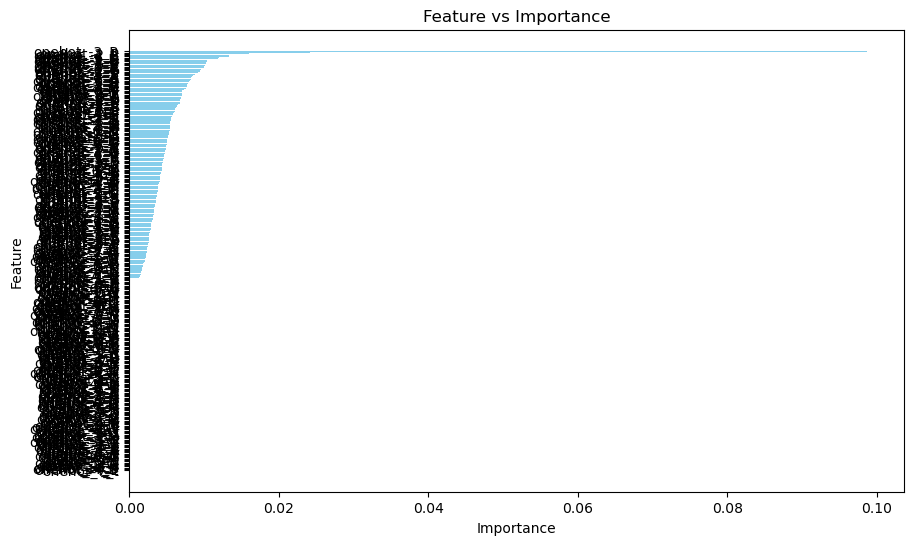

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Sorting the DataFrame based on the 'Value' column in descending order
df_sorted = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plotting the data
plt.figure(figsize=(10, 6))  # Set the figure size
plt.barh(df_sorted.iloc[:, 0], df_sorted.iloc[:, 1], color='skyblue')  # Create a horizontal bar plot

# Adding title and labels
plt.title('Feature vs Importance')
plt.ylabel(df_sorted.columns[0])
plt.xlabel(df_sorted.columns[1])

# Display the plot
plt.show()

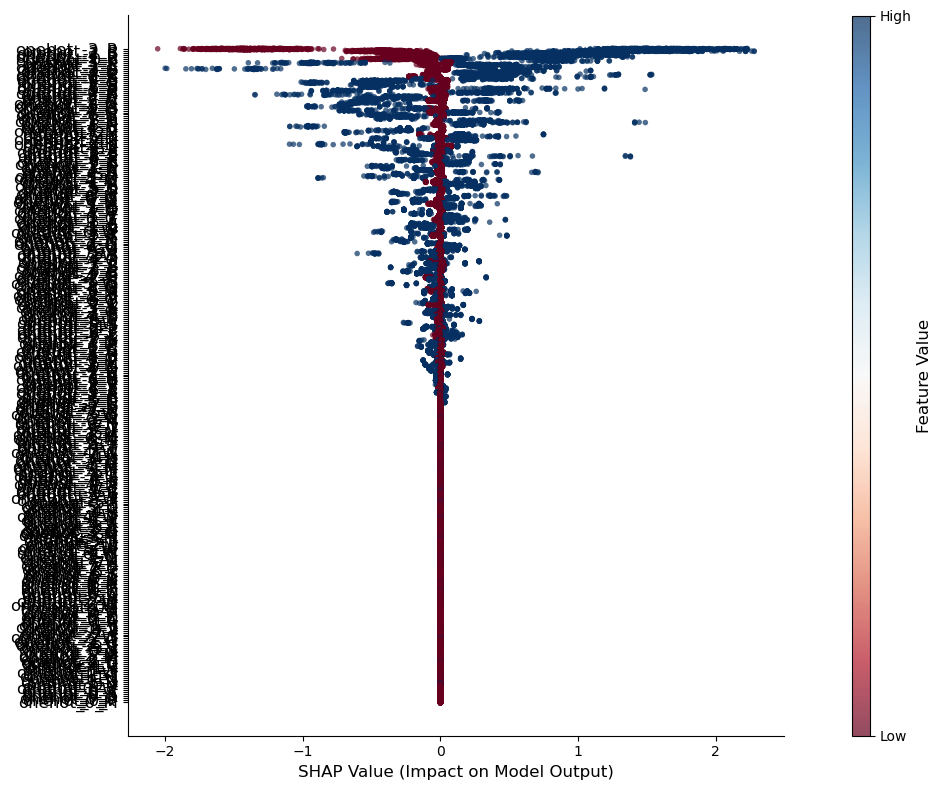

In [52]:
import shap
best_model = best_onehot_model
onehot_model = best_model.named_steps['classifier']

# Create a SHAP explainer
explainer = shap.TreeExplainer(onehot_model)

# Calculate SHAP values
shap_values = explainer(X_train[feature_names])

# # Visualize feature importance with feature values
custom_beeswarm(shap_values, feature_names)

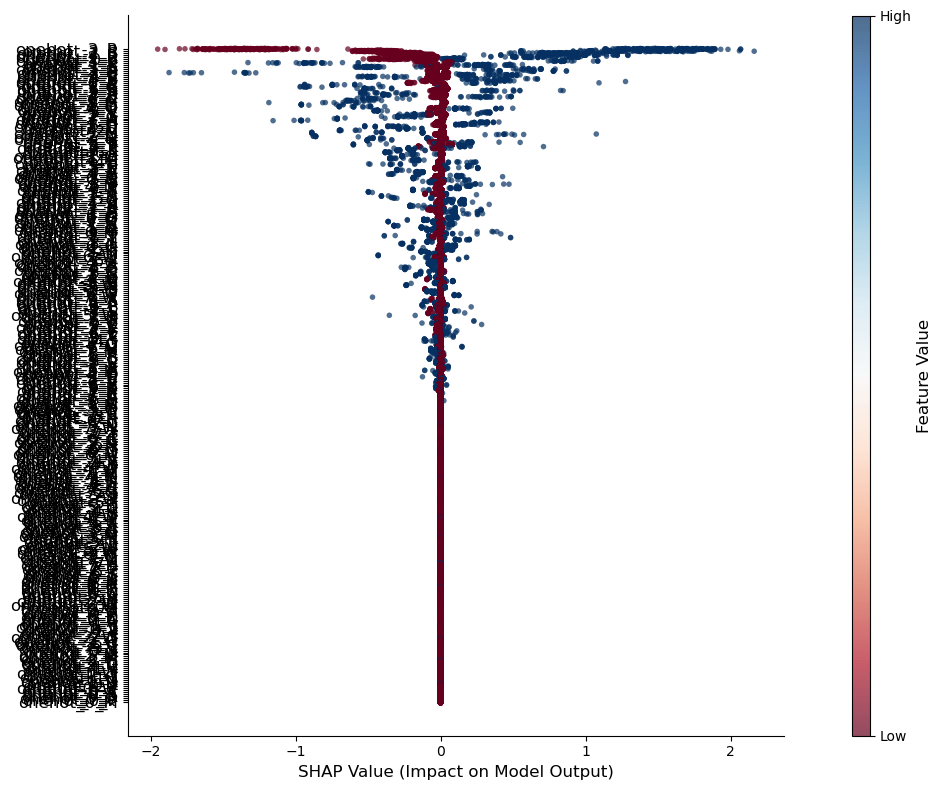

In [53]:
# for validate dataset 
# Calculate SHAP values
shap_values = explainer(X_valid[feature_names])

custom_beeswarm(shap_values, feature_names)

In [ ]:
# compare Independent datset test with 14-3-3 pred and 14-3-3 site-finder, compare with our results.

In [55]:
# get augmentated and no_augmentated training dataset, only include onehot encode feature
dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")

# get independent test dataset, only include onehot encode feature
testing_dataset_df = dataset_df[dataset_df["usage"] == "independent test"]

testing_onehot_model_dataset_df = testing_dataset_df.filter(regex=r'^(onehot_|label)')


optimal_features = ['esm_residue_embedding_482', 'esm_residue_embedding_197', 'esm_residue_embedding_844', 'onehot_1_L', 'esm_residue_embedding_715', 'esm_residue_embedding_1259', 'ptmmamba_residue_embedding_79', 'esm_residue_embedding_1074', 'iupred_score', 'esm_residue_embedding_53', 'onehot_1_P', 'onehot_-3_R', 'onehot_-1_H', 'onehot_1_R', 'esm_residue_embedding_327', 'phospho_score', 'esm_residue_embedding_1041', 'onehot_-1_K', 'onehot_-3_E', 'onehot_7_G', 'onehot_-4_R', 'esm_residue_embedding_394', 'ptmmamba_residue_embedding_408', 'onehot_2_P', 'esm_residue_embedding_546', 'onehot_-2_G', 'esm_residue_embedding_491', 'esm_residue_embedding_1215', 'onehot_-2_S', 'esm_residue_embedding_81', 'onehot_-5_R', 'onehot_3_D', 'esm_protein_embedding_68', 'nuSVR', 'esm_residue_embedding_356', 'onehot_-2_R', 'esm_residue_embedding_385', 'esm_residue_embedding_1171', 'deephase_w2v_multi', 'esm_residue_embedding_1242']
features = optimal_features + ["label"]


testing_bio_plm_model_dataset_df = testing_dataset_df[features]

In [56]:
# y = df["label"]
# target = "label"
# used_features = list(df.columns)
# used_features.remove(target)
# x = df[used_features]

# if "augmentated from uniprot ID" in x.columns:
#     x = x.drop(columns=['augmentated from uniprot ID'])
    
# # Training set evaluation
# y_proba = model.predict_proba(x)[:, 1]
# y_pred = model.predict(x)
# train_mcc = matthews_corrcoef(y, y_pred)
# model_classification_report = classification_report(y, y_pred)

# # Print evaluation results
# print("Model performance:")
# print(f"Average Precision Score: {average_precision_score(y, y_proba):.3e}")
# print(f"Matthews Correlation Coefficient: {train_mcc:.3f}")
# print(f"Classification Report (Training data):")
# print(model_classification_report)
# print("-" * 50)

In [57]:
print("onehot model performance:")
evaluation(testing_onehot_model_dataset_df, best_onehot_model)

onehot model performance:
Label counts in y:
label
0    264
1    263
Name: count, dtype: int64
Model Pipeline(steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                          

In [58]:
print("onehot model performance:")
evaluation(testing_bio_plm_model_dataset_df, best_xgboost_model)

onehot model performance:
Label counts in y:
label
0    264
1    263
Name: count, dtype: int64
Model Pipeline(steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=0.5, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                        